In [1]:
try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install -q xgboost
    from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans, DBSCAN

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Classification
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Feature Importance
from sklearn.inspection import permutation_importance

print("="*60)
print("Customer Intelligence System")
print("Libraries Imported Successfully")
print("="*60)

Customer Intelligence System
Libraries Imported Successfully


#  Step 1: Load the Dataset

> **Note on Terminology:** In this project, countries are treated as *customers* of international humanitarian aid organizations such as HELP International. Their socio-economic profiles form the foundation of the **Customer Intelligence System**, enabling data-driven decisions on resource allocation.

In this step, we upload and load the **Country-data.csv** dataset into the notebook.

This dataset contains socio-economic and health indicators for different countries and will be used to:

- Perform Exploratory Data Analysis (EDA)
- Build Classification Models
- Train Ensemble Models (Random Forest & XGBoost)
- Perform Customer Segmentation using K-Means and DBSCAN
- Generate actionable insights for humanitarian aid recommendations

**Objective:** Successfully load the dataset and verify its structure before beginning the analysis.

In [2]:
from google.colab import files

print("Please upload the 'Country-data.csv' file.")
uploaded = files.upload()

# Read dataset
df = pd.read_csv("Country-data.csv")

print("\n" + "="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)

print(f"Number of Countries : {df.shape[0]}")
print(f"Number of Features  : {df.shape[1]}")
print(f"Missing Values      : {df.isnull().sum().sum()}")
print(f"Duplicate Rows      : {df.duplicated().sum()}")

print("="*60)
df.head()

Please upload the 'Country-data.csv' file.


Saving Country-data.csv to Country-data (2).csv

DATASET LOADED SUCCESSFULLY
Number of Countries : 167
Number of Features  : 10
Missing Values      : 0
Duplicate Rows      : 0


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


###  Observation

- The dataset was loaded successfully without any errors.
- It contains **167 countries** and **10 attributes** describing socio-economic and health conditions.
- No missing values or duplicate records were detected during the initial inspection.
- The dataset is ready for detailed exploratory data analysis (EDA) and preprocessing.

#  Step 2: Configure Visualization & Define Features

Before performing analysis, we configure the notebook's visualization style and define the numerical features that will be used throughout the project.

These settings ensure:
- Consistent and professional-looking visualizations.
- A centralized list of numerical features for preprocessing, clustering, and classification.
- Improved readability and maintainability of the notebook.

In [3]:
# Professional color palettes
PALETTE = [
    "#2D6A4F", "#52B788", "#95D5B2",
    "#F4A261", "#E76F51",
    "#264653", "#457B9D", "#6A4C93"
]

CLUSTER_COLORS = [
    "#E63946", "#457B9D", "#2A9D8F",
    "#E9C46A", "#F4A261",
    "#6A4C93", "#C77DFF"
]

# Visualization settings
sns.set_theme(
    style="whitegrid",
    palette=PALETTE
)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 120
})

# Numerical features used throughout the project
FEATURE_COLS = [
    "child_mort",
    "exports",
    "health",
    "imports",
    "income",
    "inflation",
    "life_expec",
    "total_fer",
    "gdpp"
]

print("="*60)
print("NOTEBOOK CONFIGURATION COMPLETED")
print("="*60)

print(f"Total Numerical Features : {len(FEATURE_COLS)}")
print("\nFeatures Selected:")

for feature in FEATURE_COLS:
    print(f" • {feature}")

NOTEBOOK CONFIGURATION COMPLETED
Total Numerical Features : 9

Features Selected:
 • child_mort
 • exports
 • health
 • imports
 • income
 • inflation
 • life_expec
 • total_fer
 • gdpp


###  Observation

The notebook has been configured with a consistent visualization theme and a predefined list of numerical features.

These features represent key socio-economic and health indicators that will be used for:
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Clustering
- Classification
- Ensemble Learning

## Step 3. Feature Scaling and Principal Component Analysis (PCA)

Before applying clustering algorithms, all numerical features are standardized using **StandardScaler** to ensure that each feature contributes equally to the distance calculations. Principal Component Analysis (PCA) is also performed to generate two principal components for visualization purposes in later clustering plots.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prepare feature matrix
X = df[FEATURE_COLS].copy()

# Standardize features
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)

print("=" * 60)
print("FEATURE SCALING COMPLETED")
print("=" * 60)

print(f"Original Feature Matrix Shape : {X.shape}")
print(f"Scaled Feature Matrix Shape   : {X_sc.shape}")

print("\nPrincipal Component Analysis")
print(f"PC1 Explained Variance : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 Explained Variance : {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total Explained Variance : {pca.explained_variance_ratio_.sum()*100:.2f}%")

FEATURE SCALING COMPLETED
Original Feature Matrix Shape : (167, 9)
Scaled Feature Matrix Shape   : (167, 9)

Principal Component Analysis
PC1 Explained Variance : 45.95%
PC2 Explained Variance : 17.18%
Total Explained Variance : 63.13%


Observation:

• All 9 numerical features were successfully standardized before clustering.

• Feature scaling ensures that variables with larger numerical ranges do not dominate distance-based algorithms such as K-Means and DBSCAN.

• PCA reduced the dataset to two principal components for visualization while preserving 63.13% of the total variance.

• The first principal component explains 45.95% of the dataset variance, while the second explains 17.18%.

• The transformed dataset is now ready for clustering and machine learning analysis.

## Step 4: Descriptive Statistical Analysis

Before building clustering and classification models, it is important to understand the statistical characteristics of the dataset. This step summarizes the distribution of each numerical feature by computing measures such as mean, standard deviation, minimum, maximum, and quartiles. These statistics help identify feature scales, variability, and potential outliers that may influence model performance.

In [5]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS OF NUMERICAL FEATURES")
print("=" * 60)
print("Summary statistics for all socio-economic indicators\n")

desc_stats = df[FEATURE_COLS].describe().round(2)
display(desc_stats)

DESCRIPTIVE STATISTICS OF NUMERICAL FEATURES
Summary statistics for all socio-economic indicators



,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


Observation:

• The dataset contains 167 countries described using 9 numerical socio-economic and health indicators.

• No missing values are present, indicating that the dataset is complete and ready for analysis.

• The numerical features have significantly different value ranges. For example, Income ranges from 609 to 125,000, while Health expenditure ranges from 1.81 to 17.90.

• Child Mortality shows high variability (2.6 to 208), indicating substantial differences in healthcare conditions across countries.

• The wide variation in feature scales suggests that feature standardization is essential before applying clustering algorithms such as K-Means and DBSCAN.

• These descriptive statistics provide an initial understanding of the dataset and help guide the preprocessing and modeling steps in the Customer Intelligence System.

## Step 5. Exploratory Data Analysis (EDA) – Feature Distributions

This section visualizes the distribution of all numerical features using histograms. The objective is to understand the spread, central tendency, and skewness of each socio-economic indicator before applying machine learning algorithms.

The following information is highlighted:
- Distribution of each feature
- Mean and median values
- Degree of skewness
- Overall data spread and variability

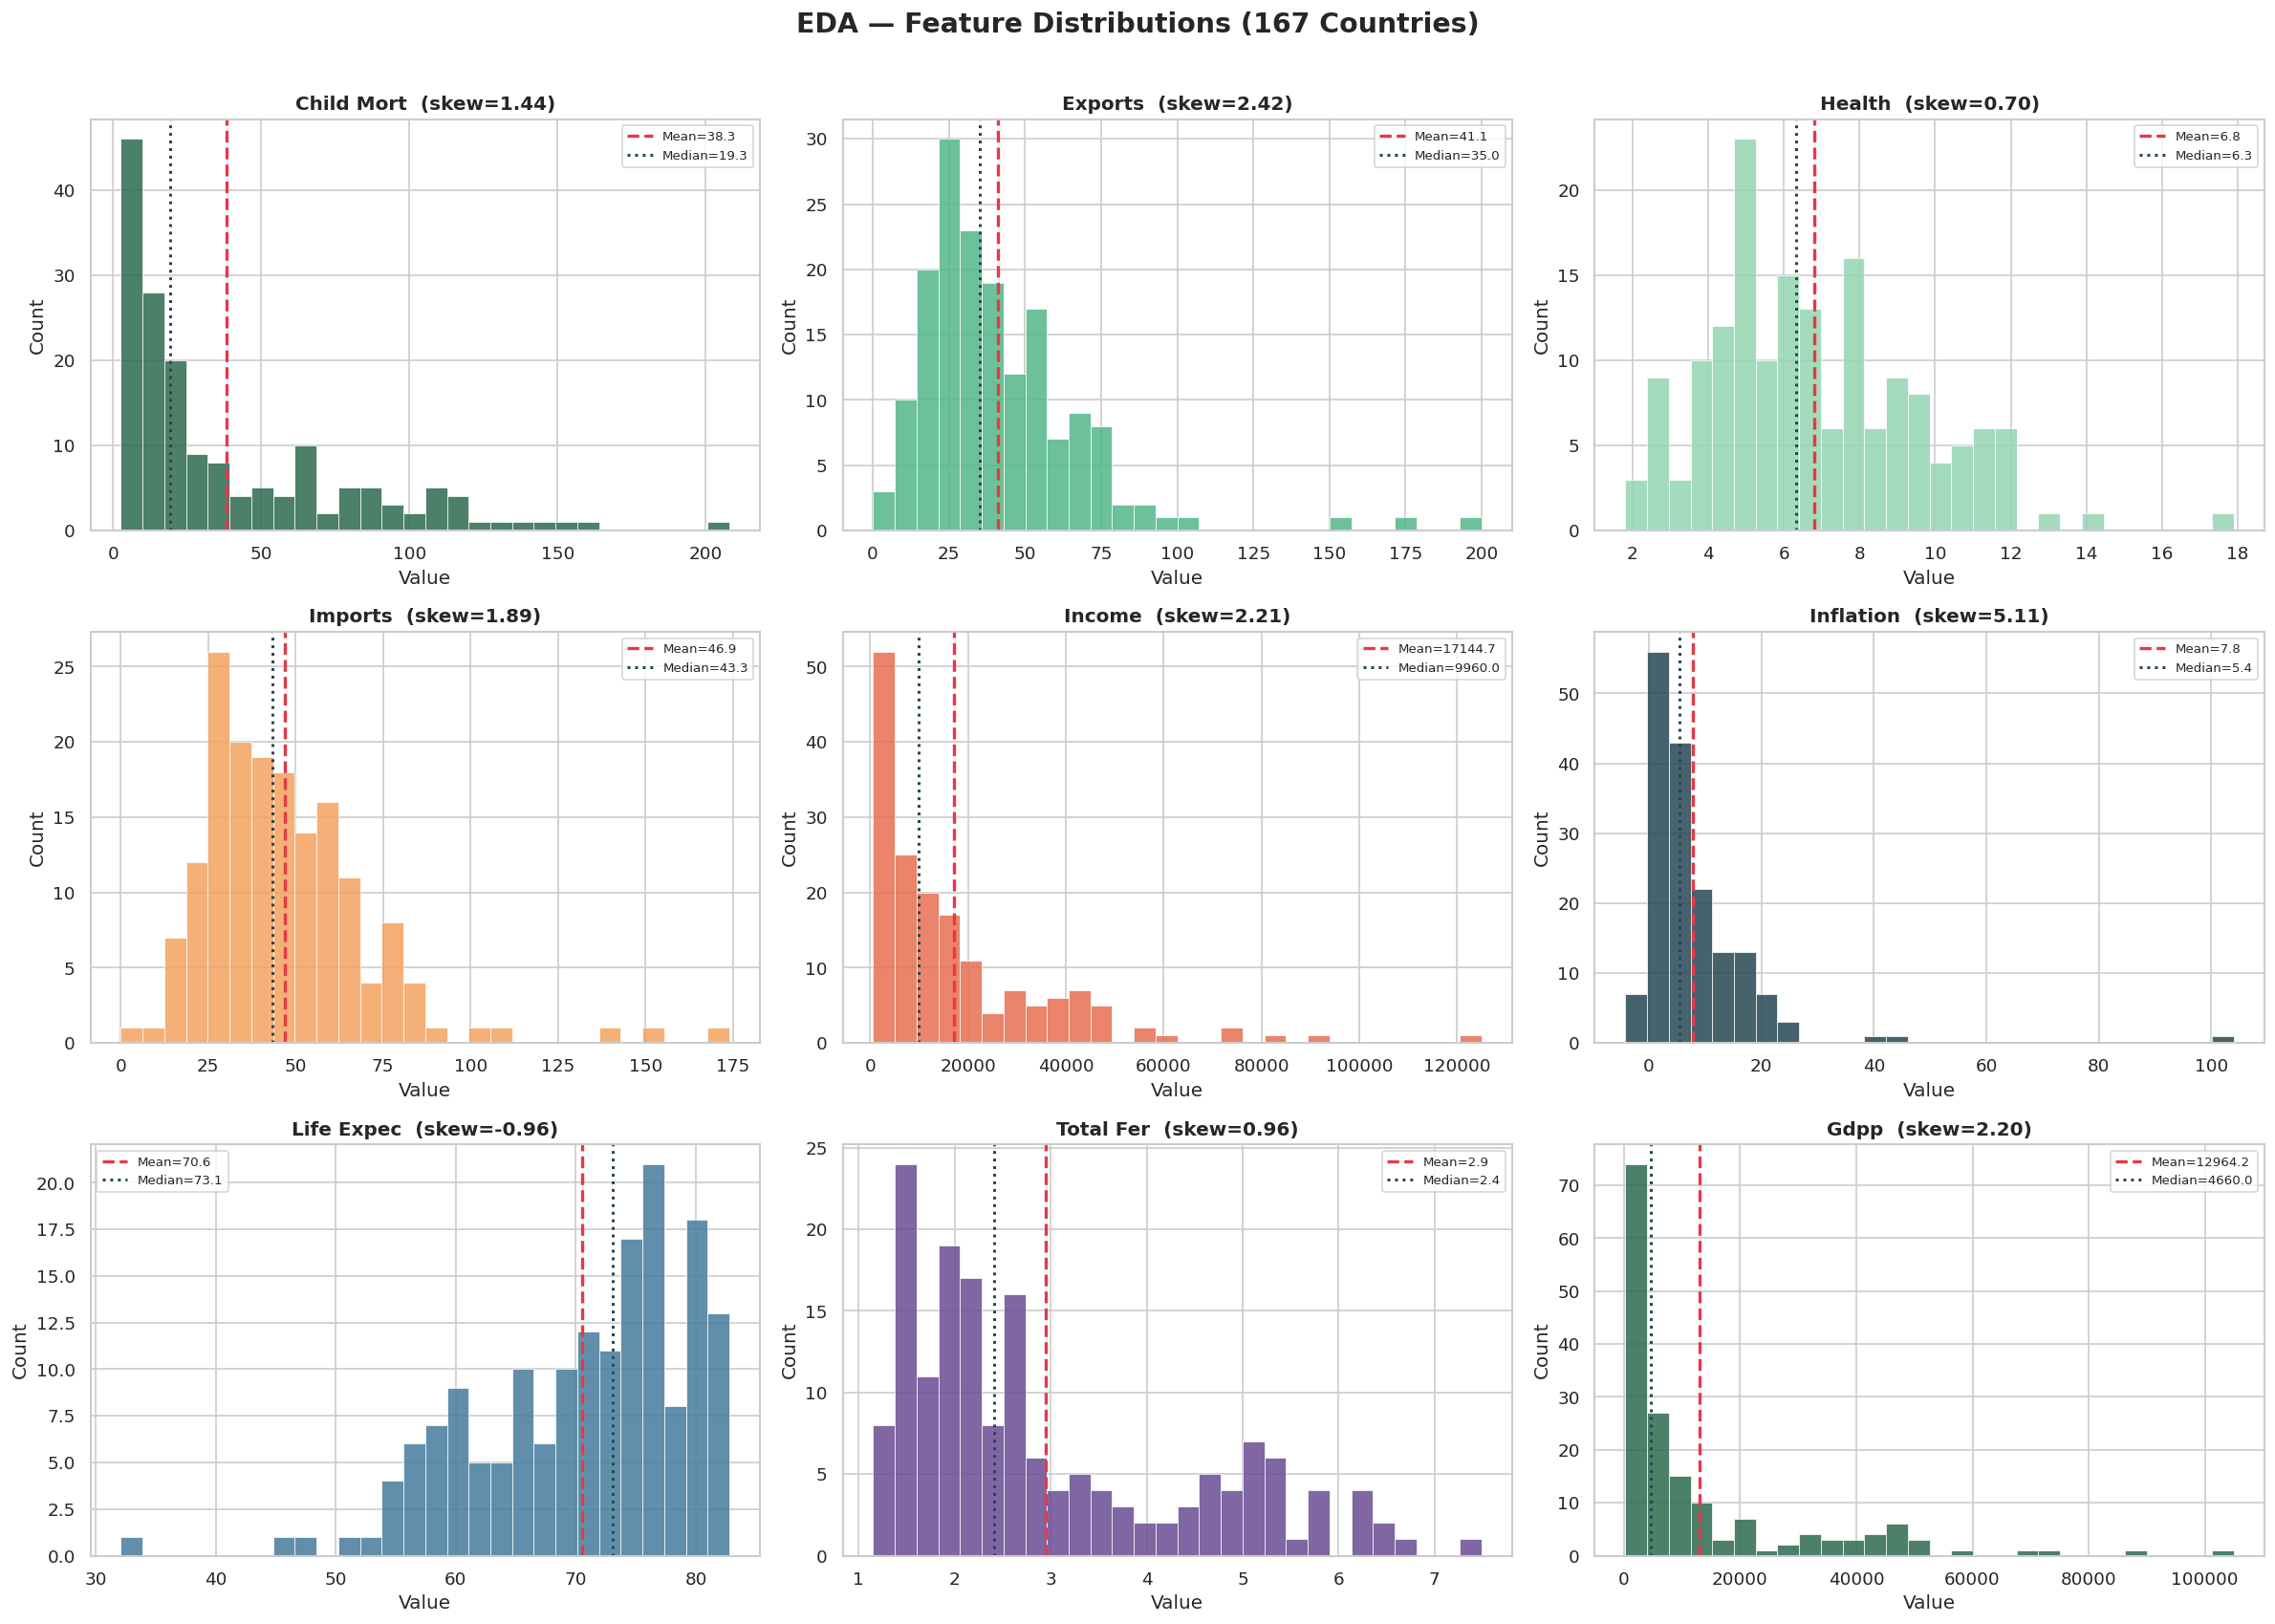

 Fig 1 saved


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.suptitle("EDA — Feature Distributions (167 Countries)",
             fontsize=17, fontweight="bold", y=1.01)

for i, col in enumerate(FEATURE_COLS):
    ax   = axes[i // 3, i % 3]
    data = df[col].dropna()
    ax.hist(data, bins=28, color=PALETTE[i % len(PALETTE)],
            edgecolor="white", linewidth=0.5, alpha=0.85)
    ax.axvline(data.mean(),   color="#E63946", lw=2, ls="--",
               label=f"Mean={data.mean():.1f}")
    ax.axvline(data.median(), color="#264653", lw=1.8, ls=":",
               label=f"Median={data.median():.1f}")
    ax.set_title(f"{col.replace('_',' ').title()}  (skew={stats.skew(data):.2f})",
                 fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_xlabel("Value"); ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("fig1_eda_distributions.png", bbox_inches="tight", facecolor="white")
plt.show()
print(" Fig 1 saved")

Observation:

• Most numerical features exhibit right-skewed distributions, indicating that a relatively small number of countries have exceptionally high values compared to the majority.

• Inflation shows the highest positive skewness (5.11), followed by Exports (2.42), Income (2.21), and GDP per capita (2.20), suggesting the presence of extreme values and economic disparities.

• Child Mortality (1.44), Imports (1.89), and Total Fertility (0.96) are also positively skewed, reflecting that only a few countries experience very high mortality and fertility rates.

• Life Expectancy is negatively skewed (-0.96), indicating that most countries have relatively higher life expectancy while only a few countries fall at the lower end.

• In several features, the mean and median differ noticeably, confirming the existence of outliers and non-normal distributions.

• These findings justify the use of feature standardization before applying clustering algorithms such as K-Means and DBSCAN, ensuring that features with larger scales do not dominate the clustering process.

## Step 6. Exploratory Data Analysis (EDA) – Outlier Detection

This section uses box plots to identify outliers in each socio-economic feature. Box plots summarize the distribution of the data using the median, interquartile range (IQR), and extreme values. Detecting outliers is important because unusual observations can significantly influence clustering algorithms and machine learning models.

The following information is highlighted:

- Identification of extreme observations using the IQR method
- Number of outliers detected in each feature
- Distribution spread and variability
- Comparison of median and quartile ranges
- Features requiring standardization before clustering

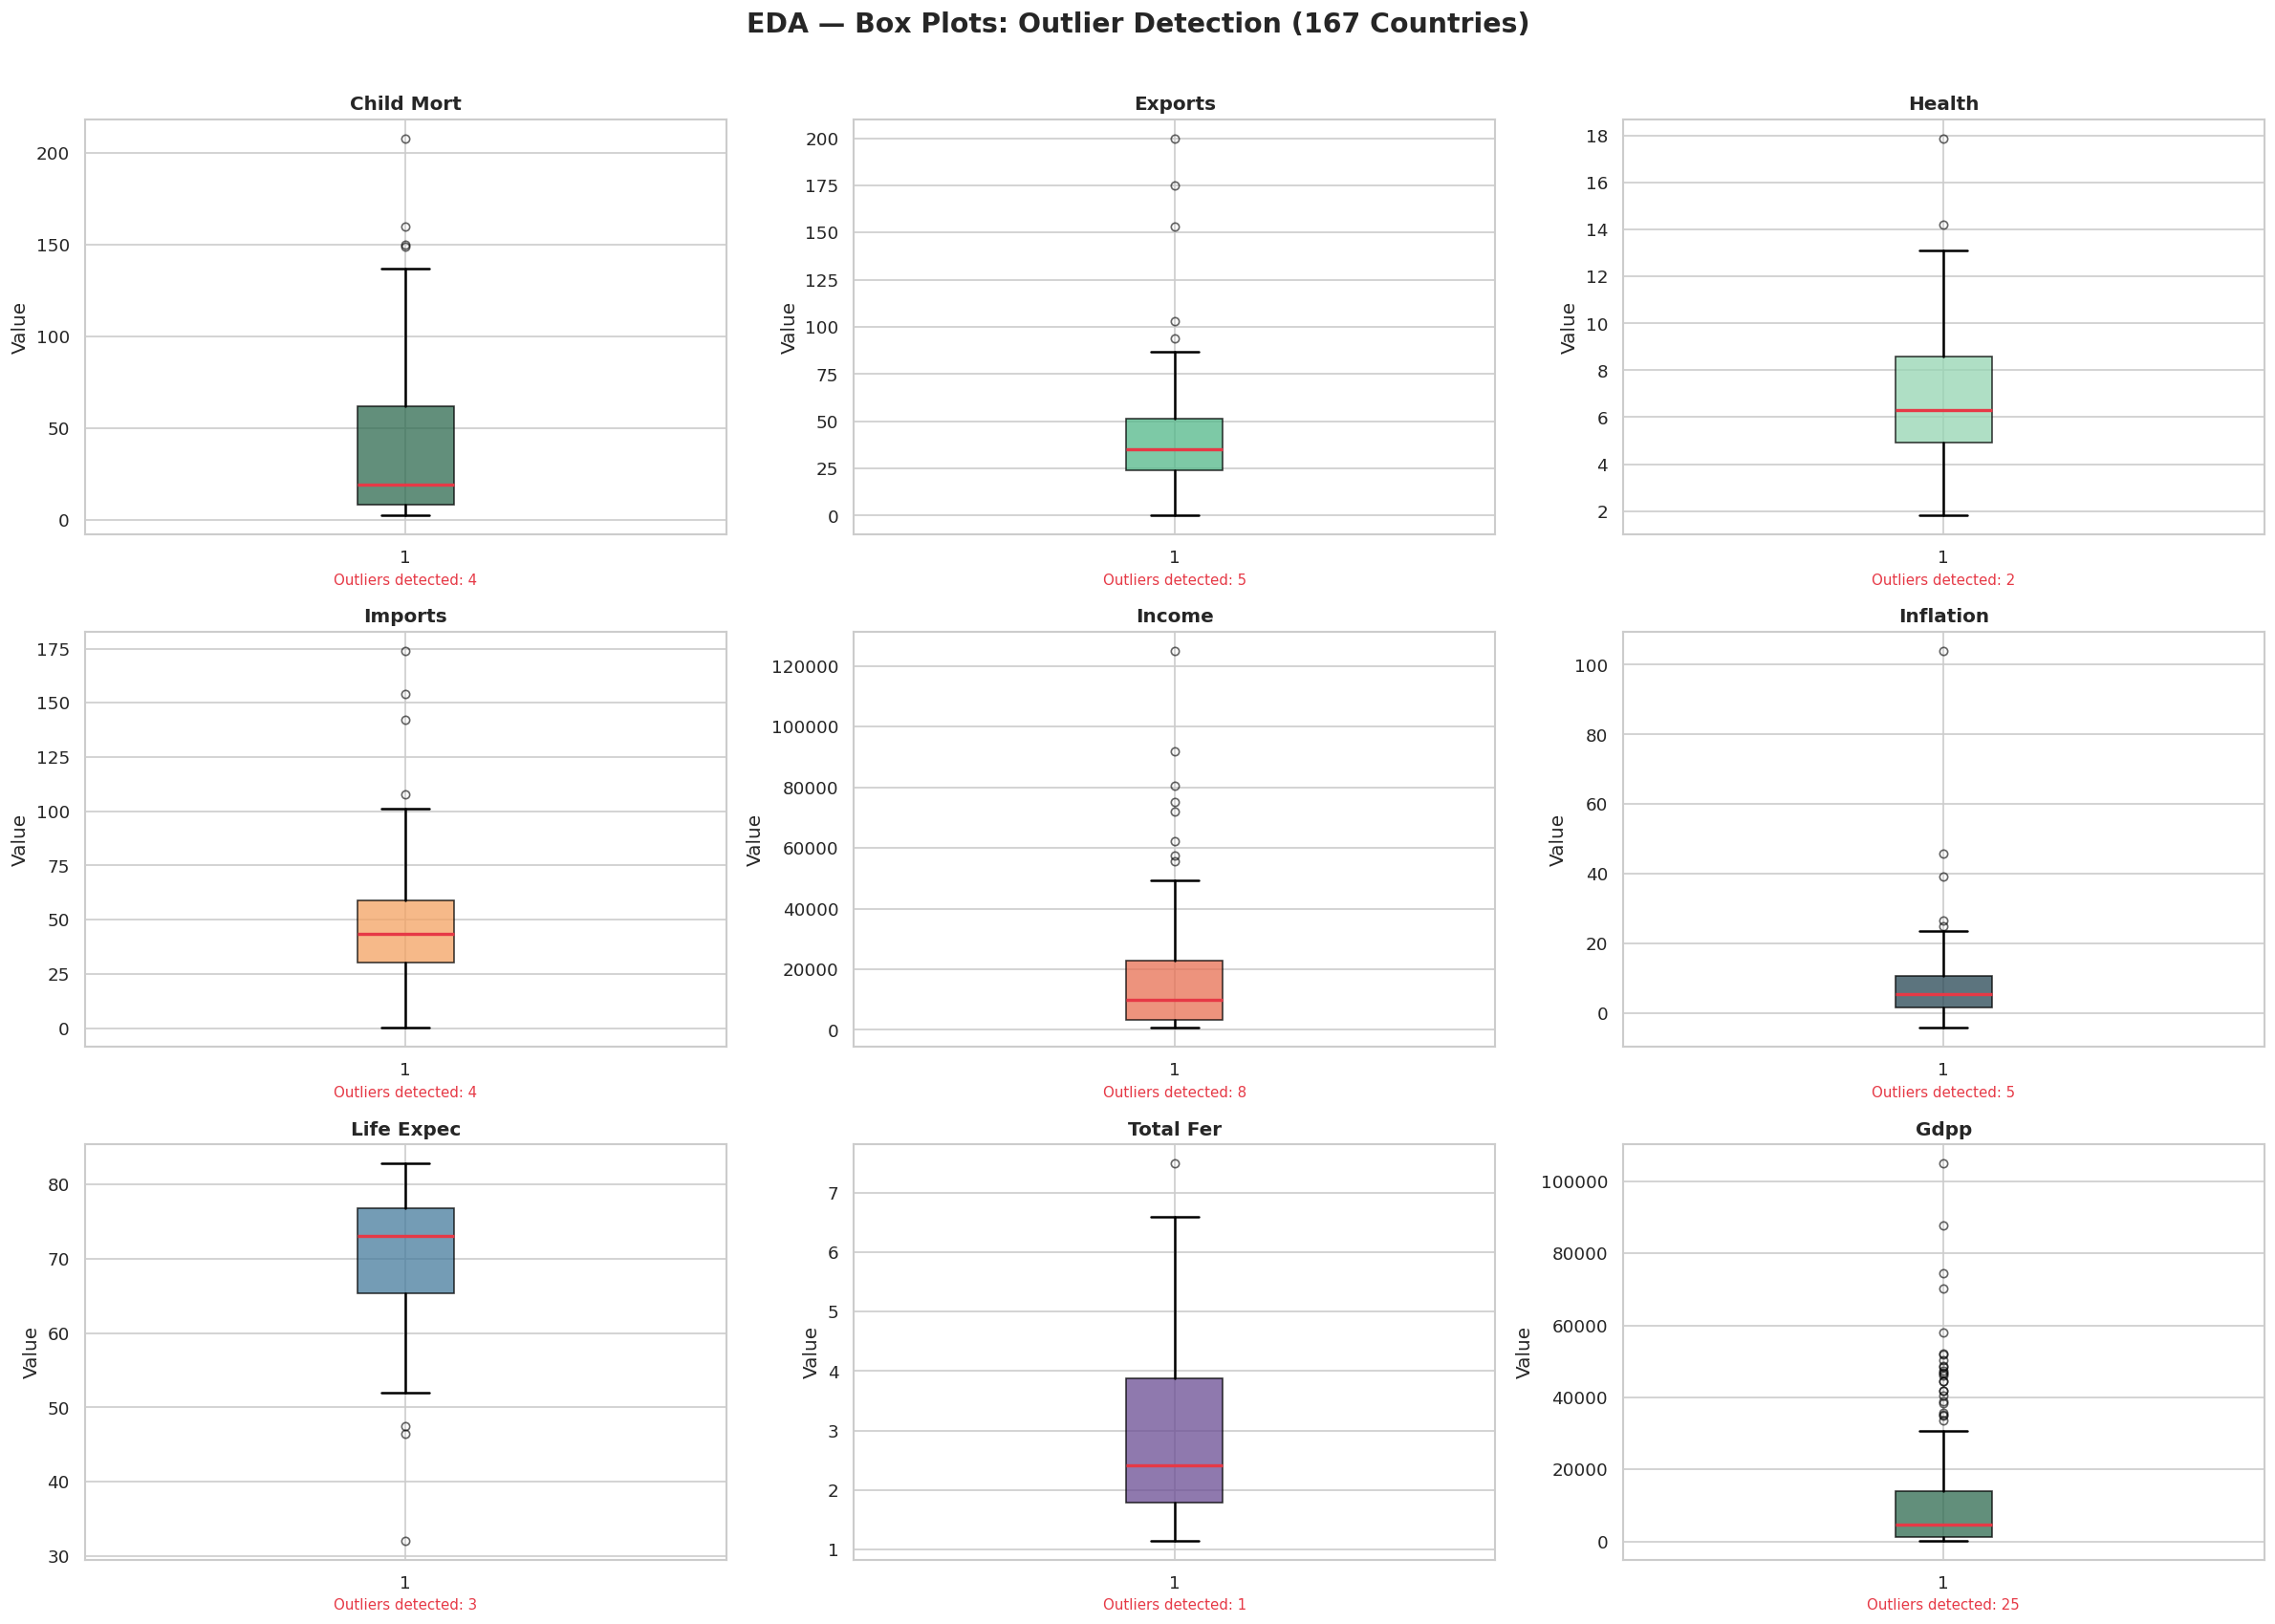

✅ Box Plot saved as fig1b_boxplots.png


In [7]:
# Box Plot — Outlier Detection

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.suptitle(
    "EDA — Box Plots: Outlier Detection (167 Countries)",
    fontsize=17,
    fontweight="bold",
    y=1.01
)

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i // 3, i % 3]
    data = df[col].dropna()

    ax.boxplot(
        data,
        patch_artist=True,
        boxprops=dict(facecolor=PALETTE[i % len(PALETTE)], alpha=0.75),
        medianprops=dict(color="#E63946", linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', color='#E63946', markersize=5, alpha=0.6)
    )

    ax.set_title(col.replace('_', ' ').title(), fontweight="bold")
    ax.set_ylabel("Value")

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)]
    ax.set_xlabel(f"Outliers detected: {len(outliers)}", fontsize=9, color="#E63946")

plt.tight_layout()
plt.savefig("fig1b_boxplots.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("\u2705 Box Plot saved as fig1b_boxplots.png")

Observation:

• Box plots reveal the presence of significant outliers across multiple socio-economic features.

• **Inflation** exhibits the most extreme outliers, with several countries recording unusually high inflation rates far above the interquartile range.

• **Income** and **GDP per capita (gdpp)** also show prominent upper outliers, reflecting the economic disparity between a small number of high-income countries and the majority.

• **Child Mortality** and **Total Fertility** contain upper outliers corresponding to severely underdeveloped nations with extreme health and demographic challenges.

• **Life Expectancy** has lower outliers representing countries with very poor health conditions.

• The presence of these outliers justifies the use of feature standardization before applying K-Means and DBSCAN, as both algorithms are sensitive to the scale and distribution of input features.

## Step 7. Correlation Analysis

A correlation heatmap is generated to examine the relationships among all numerical features. This helps identify strongly correlated variables, understand dependencies, and assess potential multicollinearity before applying clustering and machine learning models.

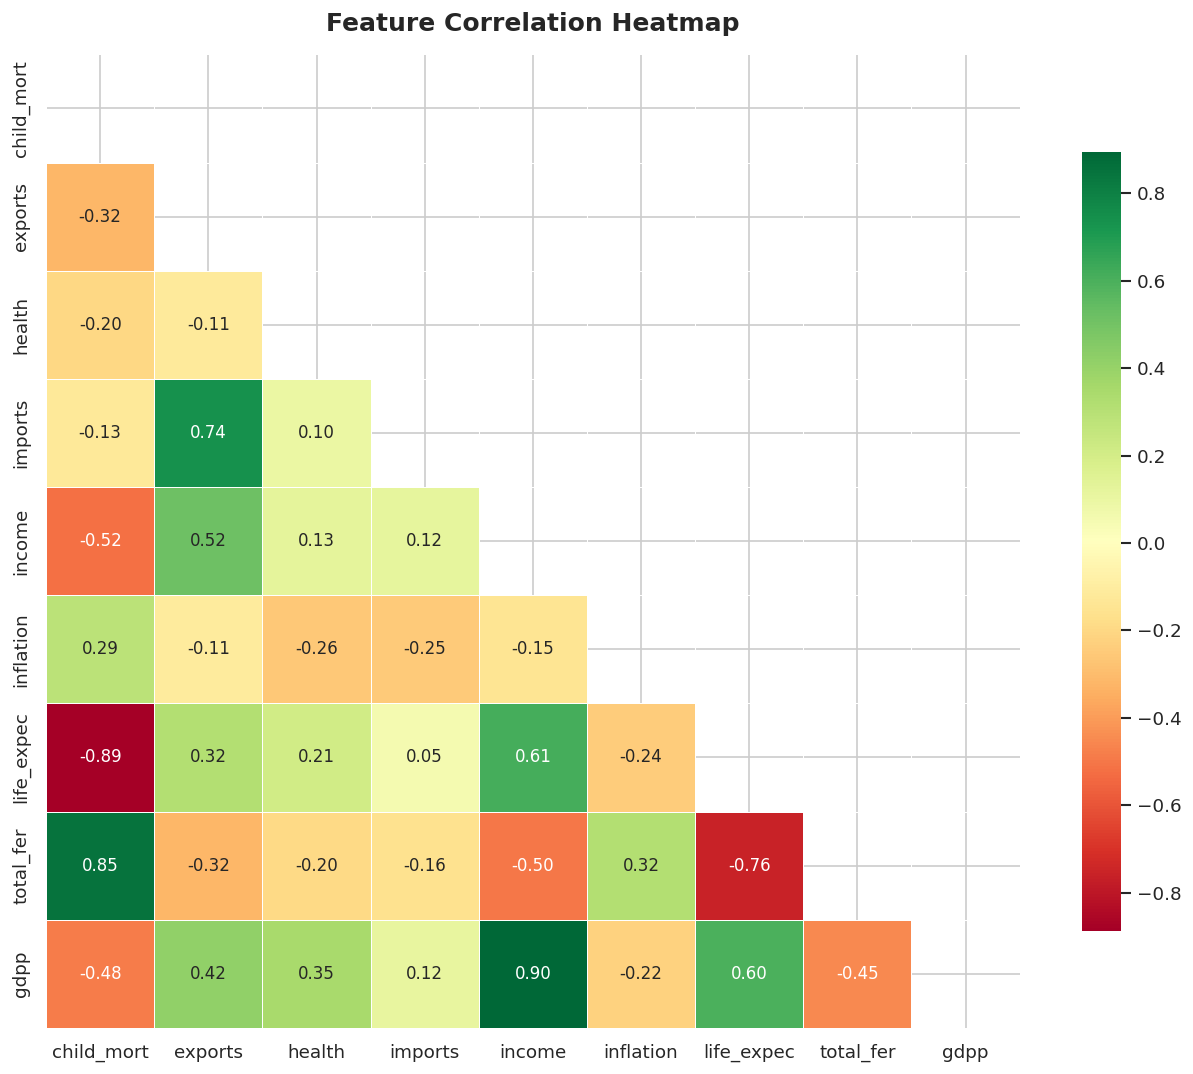

 Figure 2 saved successfully.


In [8]:
# Correlation Analysis

fig, ax = plt.subplots(figsize=(11, 9))

corr = df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.6,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 10},
    square=True,
    cbar_kws={"shrink": 0.8}
)

ax.set_title(
    "Feature Correlation Heatmap",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.tight_layout()
plt.savefig("fig2_correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white")
plt.show()

print(" Figure 2 saved successfully.")

Observations:

• A strong negative correlation (-0.89) exists between child mortality and life expectancy, indicating that countries with higher child mortality generally have lower life expectancy.

• GDP per capita (gdpp) shows a very strong positive correlation (0.90) with income, suggesting that wealthier countries typically have higher per capita GDP.

• Life expectancy is positively correlated with income (0.61) and GDP per capita (0.60), indicating better socio-economic conditions are associated with longer life expectancy.

• Total fertility has a strong positive correlation (0.85) with child mortality and a strong negative correlation (-0.76) with life expectancy, highlighting demographic differences between developed and developing countries.

• Exports and imports exhibit a strong positive correlation (0.74), showing that countries with higher export activity generally also have higher import activity.

• Inflation has relatively weak correlations with most variables, suggesting that it behaves more independently compared to other socio-economic indicators.

• Overall, the heatmap reveals meaningful relationships among economic, health, and demographic indicators, making these features suitable for clustering and predictive modeling.

## Step 8. Determining the Optimal Number of Clusters

Before applying K-Means clustering, the optimal number of clusters (K) is determined using three evaluation metrics:

- **Elbow Method** – identifies the point where adding more clusters provides diminishing improvement.
- **Silhouette Score** – measures how well-separated and compact the clusters are (higher is better).
- **Davies–Bouldin Index** – evaluates cluster similarity (lower is better).

Using multiple evaluation metrics ensures that the selected number of clusters is both statistically valid and interpretable.

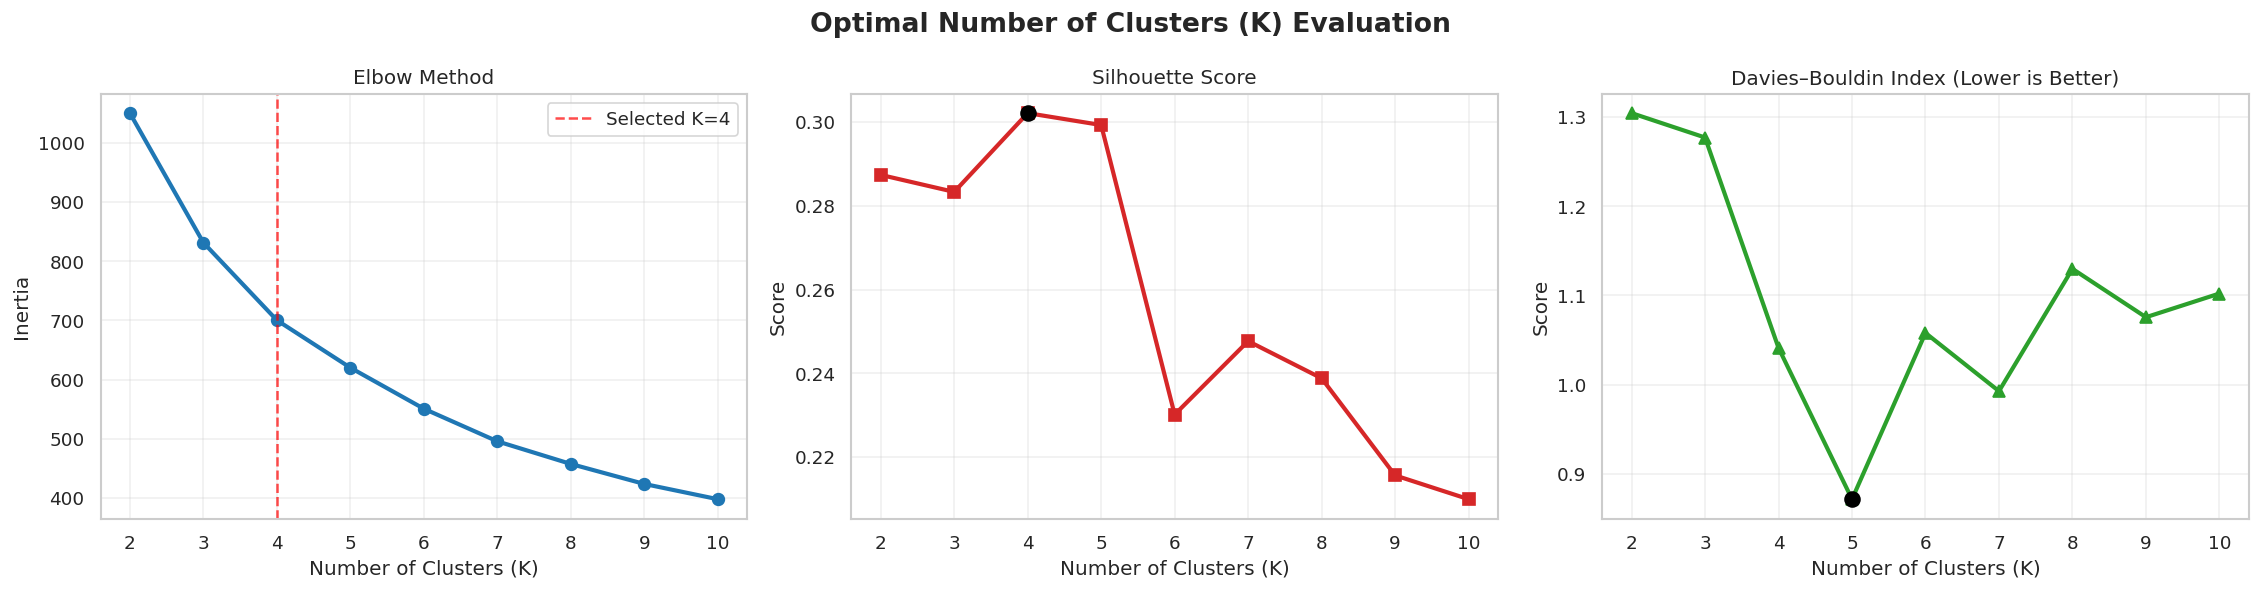

OPTIMAL CLUSTER ANALYSIS COMPLETED
Best K (Silhouette Score)      : 4
Maximum Silhouette Score       : 0.302
Minimum Davies-Bouldin Index   : 0.872

Selected K = 4 for subsequent K-Means clustering.
Figure saved as : fig3_optimal_k.png


In [9]:
inertias = []
silhouette_scores = []
db_scores = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )

    labels = kmeans.fit_predict(X_sc)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_sc, labels)
    )
    db_scores.append(
        davies_bouldin_score(X_sc, labels)
    )

# Identify Best K

best_k = K_range[np.argmax(silhouette_scores)]
best_silhouette = max(silhouette_scores)
best_db = min(db_scores)

# Visualization

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

fig.suptitle(
    "Optimal Number of Clusters (K) Evaluation",
    fontsize=16,
    fontweight="bold"
)

# Elbow

axes[0].plot(
    K_range,
    inertias,
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#1f77b4"
)

axes[0].axvline(
    best_k,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"Selected K={best_k}"
)

axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)
axes[0].legend()


# Silhouette

axes[1].plot(
    K_range,
    silhouette_scores,
    marker="s",
    linewidth=2.5,
    markersize=7,
    color="#d62728"
)

axes[1].scatter(
    best_k,
    best_silhouette,
    color="black",
    s=80,
    zorder=5
)

axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Score")
axes[1].grid(alpha=0.3)


# Davies-Bouldin

axes[2].plot(
    K_range,
    db_scores,
    marker="^",
    linewidth=2.5,
    markersize=7,
    color="#2ca02c"
)

axes[2].scatter(
    K_range[np.argmin(db_scores)],
    best_db,
    color="black",
    s=80,
    zorder=5
)

axes[2].set_title("Davies–Bouldin Index (Lower is Better)")
axes[2].set_xlabel("Number of Clusters (K)")
axes[2].set_ylabel("Score")
axes[2].grid(alpha=0.3)


plt.tight_layout()

plt.savefig(
    "fig3_optimal_k.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# Summary
print("=" * 60)
print("OPTIMAL CLUSTER ANALYSIS COMPLETED")
print("=" * 60)

print(f"Best K (Silhouette Score)      : {best_k}")
print(f"Maximum Silhouette Score       : {best_silhouette:.3f}")
print(f"Minimum Davies-Bouldin Index   : {best_db:.3f}")

print(f"\nSelected K = {best_k} for subsequent K-Means clustering.")
print("Figure saved as : fig3_optimal_k.png")

Observation:

• The Elbow Method indicates a noticeable decrease in inertia up to K = 4, after which the rate of improvement gradually declines, suggesting an appropriate clustering point.

• The highest Silhouette Score of 0.302 is obtained at K = 4, indicating the best balance between cluster cohesion and cluster separation.

• The minimum Davies–Bouldin Index (0.872) occurs at K = 5, while K = 4 provides a comparable value with superior Silhouette performance.

• Based on all three evaluation metrics, K = 4 was selected as the optimal number of clusters for K-Means clustering.

• The selected value provides well-separated, compact, and interpretable clusters, making it suitable for subsequent country segmentation analysis.

## Step 9: Final K-Means Clustering

After identifying the optimal number of clusters using the Elbow Method, Silhouette Score, and Davies–Bouldin Index, the K-Means algorithm is trained using the selected value of K.

The resulting clusters are evaluated using multiple clustering quality metrics and are interpreted by mapping them into meaningful development categories based on average GDP per capita.

This step provides the primary customer/country segmentation that will later be used for classification models.

In [10]:
FINAL_K = best_k      # Selected from previous evaluation

km_final = KMeans(
    n_clusters=FINAL_K,
    n_init=25,
    random_state=42
)

km_labels = km_final.fit_predict(X_sc)

df["Cluster"] = km_labels


# Clustering Evaluation Metrics

km_sil = silhouette_score(X_sc, km_labels)
km_ch = calinski_harabasz_score(X_sc, km_labels)
km_db = davies_bouldin_score(X_sc, km_labels)


# Cluster Profiling

cluster_means = (
    df
    .groupby("Cluster")[FEATURE_COLS]
    .mean()
)

# Rank clusters according to GDP per capita
sorted_clusters = cluster_means["gdpp"].sort_values().index.tolist()

labels = [
    "Underdeveloped",
    "Developing",
    "Upper-Middle",
    "Developed"
]

development_labels = {}

for cluster, label in zip(sorted_clusters, labels):
    development_labels[cluster] = label

df["Development_Level"] = df["Cluster"].map(development_labels)


# Results

print("=" * 65)
print("FINAL K-MEANS CLUSTERING RESULTS")
print("=" * 65)

print(f"Selected Number of Clusters : {FINAL_K}")
print(f"Silhouette Score            : {km_sil:.3f}")
print(f"Calinski-Harabasz Score     : {km_ch:.2f}")
print(f"Davies-Bouldin Index        : {km_db:.3f}")

print("\nCluster Labels")
for k, v in development_labels.items():
    print(f"Cluster {k}  →  {v}")

print("\nCountries per Cluster")
print(df["Development_Level"].value_counts().to_string())

print("\nCluster-wise Average Socio-Economic Indicators")
display(cluster_means.round(2))

print("\n✓ Cluster profiling completed successfully.")

FINAL K-MEANS CLUSTERING RESULTS
Selected Number of Clusters : 4
Silhouette Score            : 0.302
Calinski-Harabasz Score     : 62.26
Davies-Bouldin Index        : 1.041

Cluster Labels
Cluster 2  →  Underdeveloped
Cluster 0  →  Developing
Cluster 3  →  Upper-Middle
Cluster 1  →  Developed

Countries per Cluster
Development_Level
Developing        88
Underdeveloped    46
Upper-Middle      30
Developed          3

Cluster-wise Average Socio-Economic Indicators


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,21.74,41.32,6.26,48.08,12972.39,7.43,72.76,2.29,6912.64
1,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67
2,93.84,28.84,6.35,42.13,3738.98,12.09,59.23,5.05,1826.13
3,4.95,45.83,9.17,39.74,45250.00,2.74,80.38,1.80,43333.33



✓ Cluster profiling completed successfully.


Observations:

• K-Means clustering was performed using the optimal number of clusters (K = 4), selected from the previous cluster evaluation step.

• The clustering model achieved a Silhouette Score of 0.302, indicating a reasonable level of separation between the identified clusters.

• The Calinski–Harabasz Score of 62.26 suggests that the clusters are compact and well separated.

• The Davies–Bouldin Index of 1.041 indicates acceptable clustering quality, where lower values represent better-defined clusters.

• The dataset was segmented into four development categories:
  - Developing : 88 countries
  - Underdeveloped : 46 countries
  - Upper-Middle : 30 countries
  - Developed : 3 countries

• The Developed cluster has the highest average GDP per capita, income, life expectancy, and export levels, while also showing the lowest child mortality and fertility rates.

• The Underdeveloped cluster exhibits the lowest income and GDP per capita along with the highest child mortality, inflation, and fertility rates, indicating countries that require greater developmental support.

• The Developing and Upper-Middle clusters represent intermediate socio-economic conditions, highlighting the gradual transition between underdeveloped and developed nations.

• Overall, the clustering successfully groups countries with similar socio-economic characteristics, providing meaningful segments that can support data-driven decision-making and resource allocation.

## Step 10: PCA Visualization of K-Means Clusters

To better understand the clustering results, Principal Component Analysis (PCA) is used to project the 9-dimensional feature space into two principal components while preserving most of the variance.

Each point represents a country, colored according to its assigned cluster. Selected countries are annotated to highlight their positions within the socio-economic landscape.

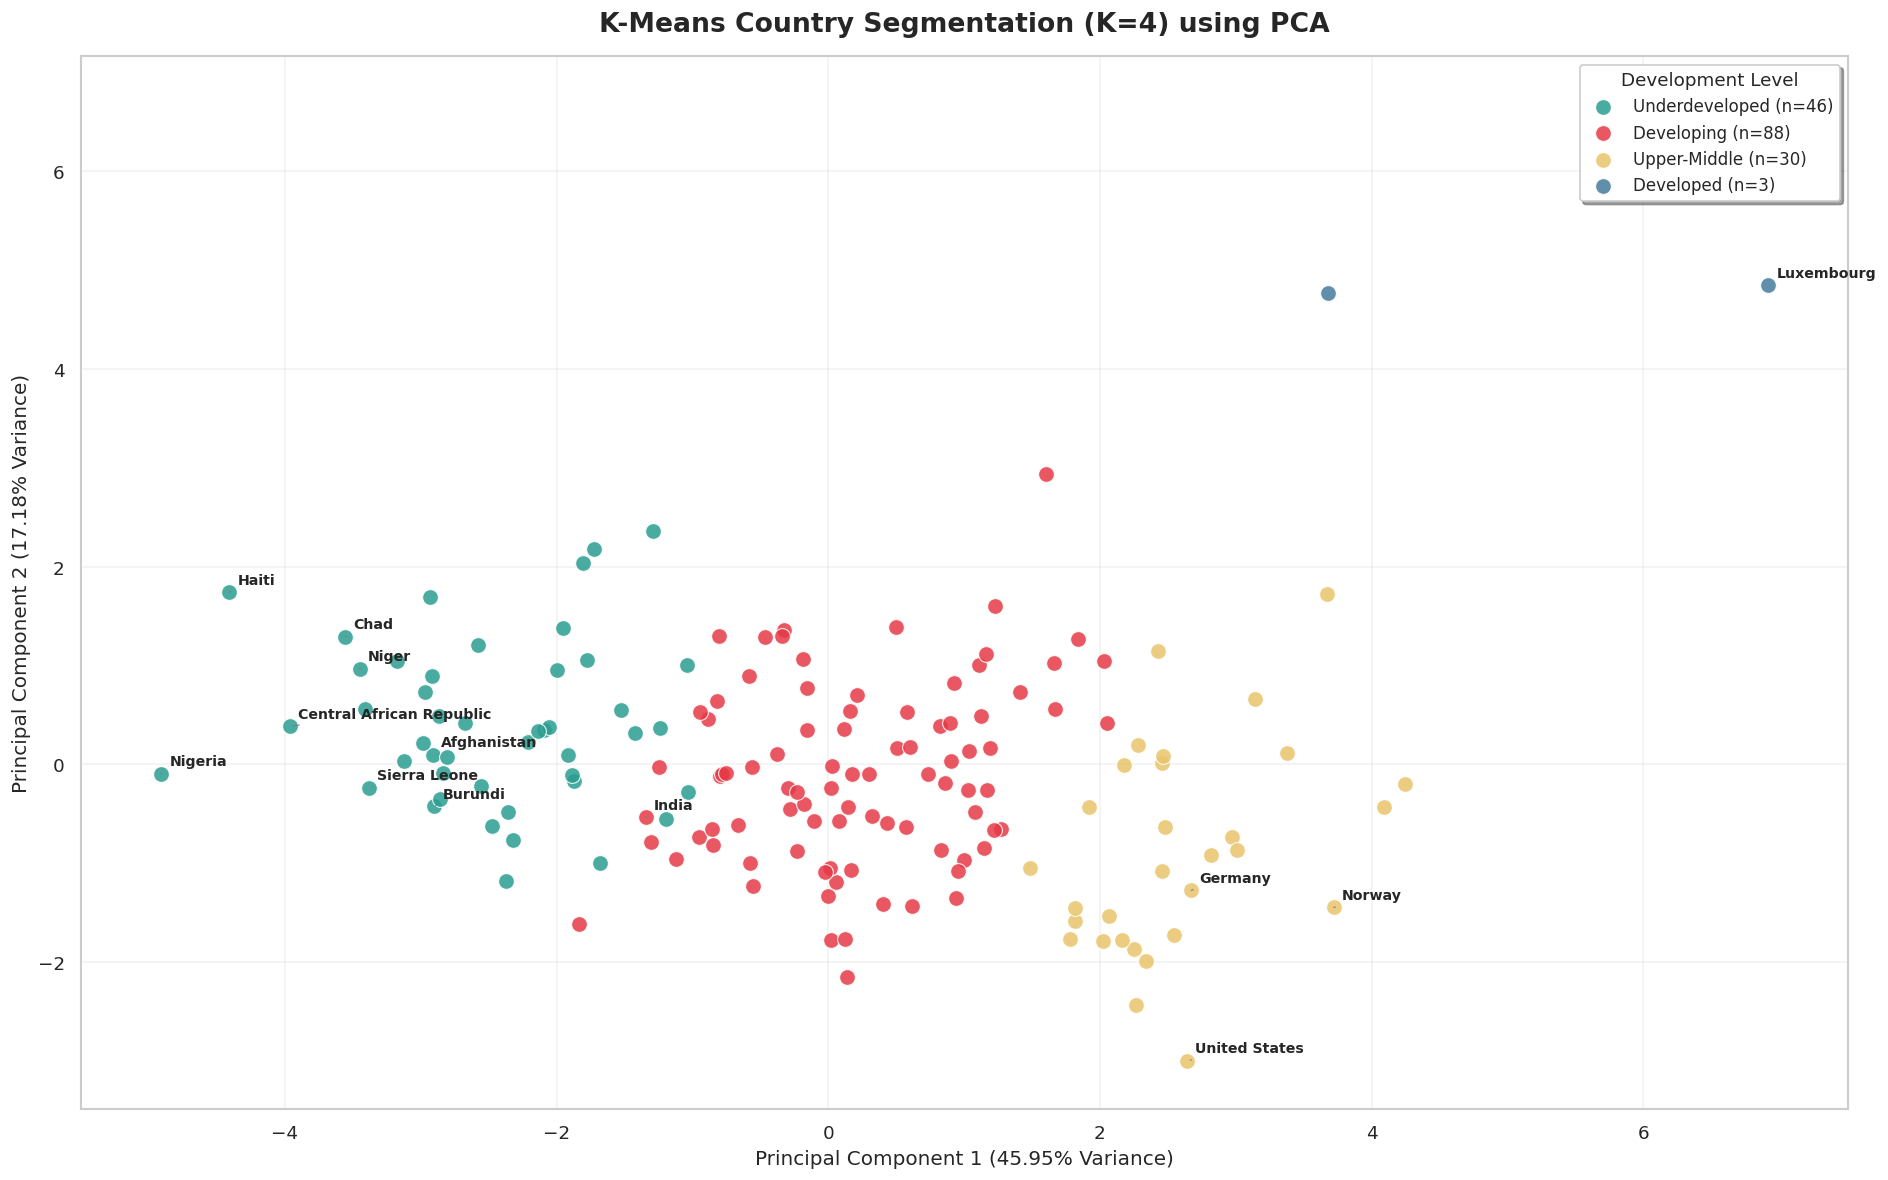

PCA CLUSTER VISUALIZATION COMPLETED
Clusters Visualized : 4
PC1 Variance        : 45.95%
PC2 Variance        : 17.18%
Total Variance      : 63.13%
Figure saved as     : fig4_kmeans_pca.png


In [11]:
fig, ax = plt.subplots(figsize=(16, 10))

for cluster in range(FINAL_K):

    mask = km_labels == cluster

    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=90,
        alpha=0.85,
        color=CLUSTER_COLORS[cluster],
        edgecolors="white",
        linewidths=0.7,
        label=f"{development_labels[cluster]} (n={mask.sum()})"
    )


# Annotate Important Countries

notable_countries = [
    "Afghanistan",
    "Burundi",
    "Central African Republic",
    "Chad",
    "Germany",
    "Haiti",
    "India",
    "Luxembourg",
    "Nigeria",
    "Niger",
    "Norway",
    "Sierra Leone",
    "Singapore",
    "United States"
]

for idx, row in df.iterrows():

    if row["country"] in notable_countries:

        ax.annotate(
            row["country"],
            (X_pca[idx, 0], X_pca[idx, 1]),
            fontsize=8.5,
            fontweight="bold",
            xytext=(5, 5),
            textcoords="offset points",
            arrowprops=dict(
                arrowstyle="-",
                color="gray",
                lw=0.7
            )
        )


# Formatting

ax.set_title(
    f"K-Means Country Segmentation (K={FINAL_K}) using PCA",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)",
    fontsize=12
)

ax.set_ylabel(
    f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)",
    fontsize=12
)

ax.grid(alpha=0.25)


# Arrange Legend in Logical Order

handles, labels = ax.get_legend_handles_labels()

desired_order = [
    "Underdeveloped",
    "Developing",
    "Upper-Middle",
    "Developed"
]

ordered_handles = []
ordered_labels = []

for level in desired_order:
    for h, l in zip(handles, labels):
        if l.startswith(level):
            ordered_handles.append(h)
            ordered_labels.append(l)

ax.legend(
    ordered_handles,
    ordered_labels,
    title="Development Level",
    title_fontsize=11,
    fontsize=10,
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.tight_layout()

plt.savefig(
    "fig4_kmeans_pca.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("=" * 60)
print("PCA CLUSTER VISUALIZATION COMPLETED")
print("=" * 60)
print(f"Clusters Visualized : {FINAL_K}")
print(f"PC1 Variance        : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 Variance        : {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total Variance      : {pca.explained_variance_ratio_.sum()*100:.2f}%")
print("Figure saved as     : fig4_kmeans_pca.png")

Observation:

• The PCA visualization projects the standardized socio-economic data into two principal components, which together explain 63.13% of the total dataset variance (PC1 = 45.95%, PC2 = 17.18%).

• K-Means successfully partitions the 167 countries into four distinct socio-economic clusters with minimal overlap, indicating effective separation in the reduced feature space.

• Underdeveloped countries such as Afghanistan, Chad, Burundi, Haiti, and Sierra Leone are concentrated on the left side of the plot, reflecting similar socio-economic characteristics including lower GDP per capita and higher child mortality.

• Developing countries form the largest cluster and occupy the central region of the PCA space, representing countries with moderate socio-economic indicators.

• Upper-middle-income countries appear between the developing and developed groups, acting as a transition cluster with stronger economic performance and improved health indicators.

• Developed countries, including Luxembourg, Norway, Germany, Singapore, and the United States, are clearly separated from the remaining clusters due to their high income, higher life expectancy, and superior development indicators.

• Overall, the PCA projection preserves the cluster structure effectively, demonstrating that K-Means has successfully identified meaningful socio-economic groupings among countries.

## Step 11: Comparison of K-Means and DBSCAN Clustering

This section compares the partition-based K-Means algorithm with the density-based DBSCAN algorithm. While K-Means assigns every country to a predefined cluster, DBSCAN identifies dense regions and automatically detects outliers (noise points). This comparison highlights the strengths and limitations of both clustering techniques.

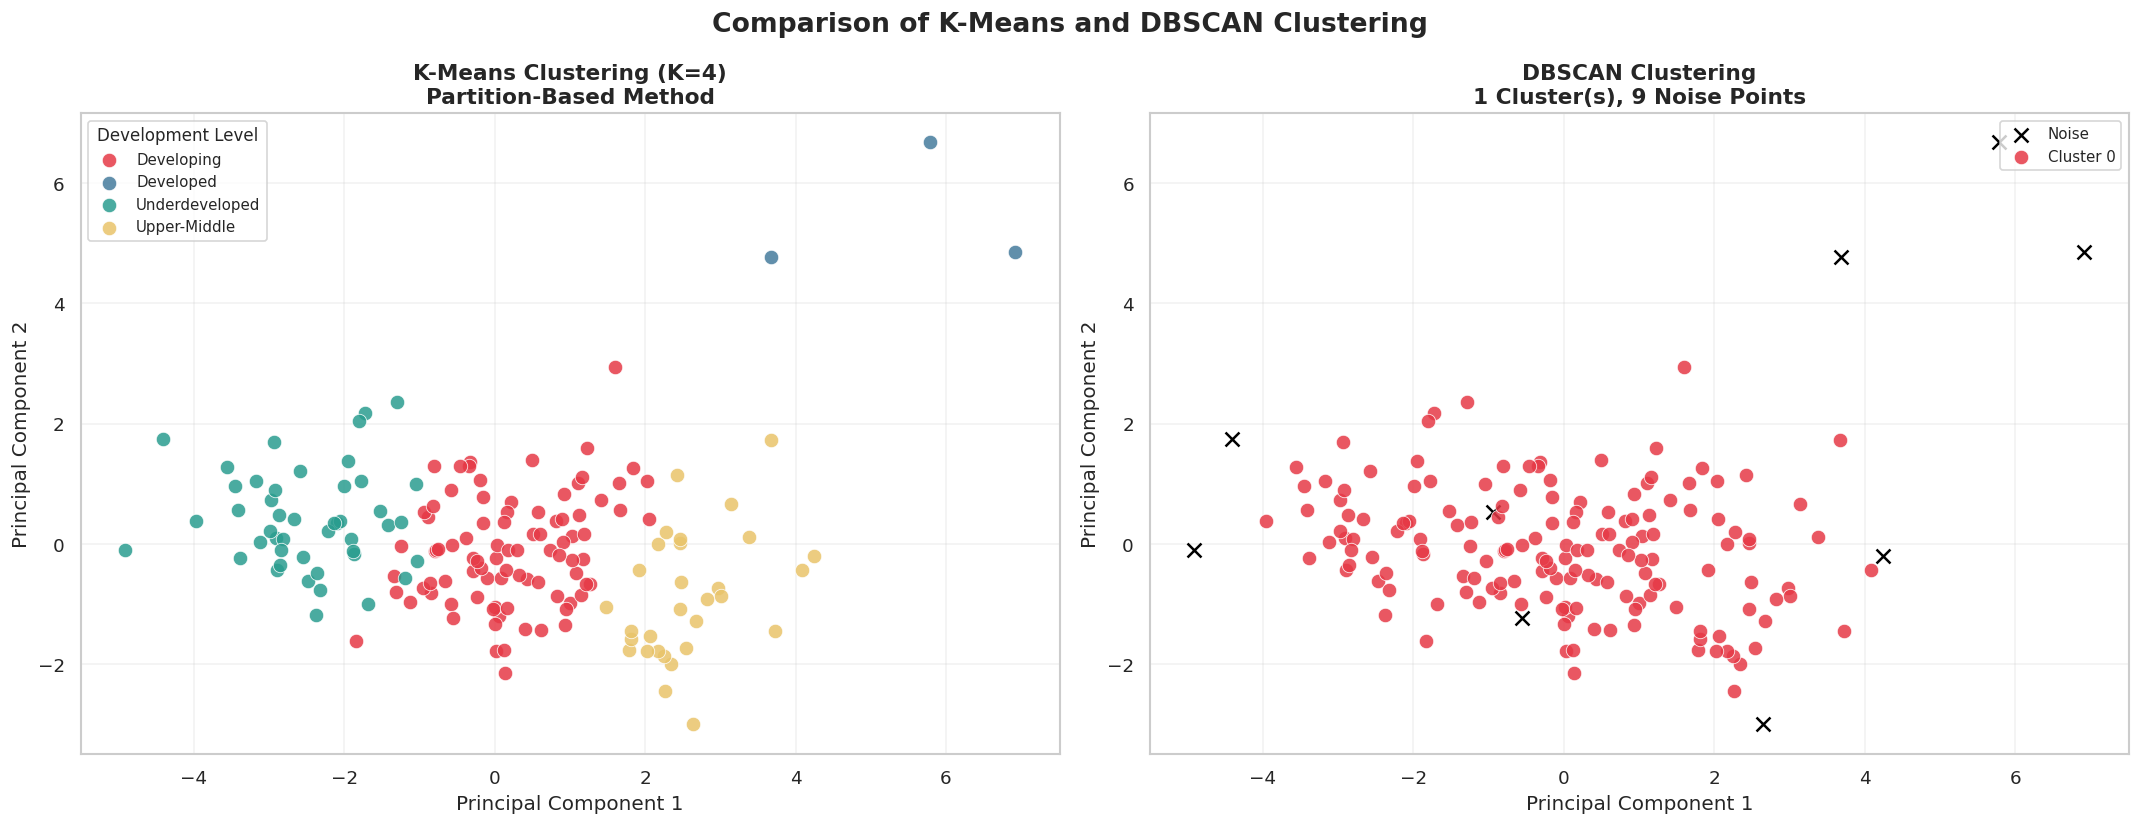

CLUSTERING COMPARISON COMPLETED
K-Means Clusters      : 4
DBSCAN Clusters       : 1
Noise Points Detected : 9

Interpretation : K-Means provides better segmentation for this dataset,
                 while DBSCAN primarily identifies outlier countries.

Figure saved as : fig5_clustering_comparison.png


In [12]:
dbscan = DBSCAN(
    eps=2.2,
    min_samples=4
)

db_labels = dbscan.fit_predict(X_sc)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = np.sum(db_labels == -1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for cluster in range(FINAL_K):

    mask = km_labels == cluster

    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=75,
        alpha=0.85,
        color=CLUSTER_COLORS[cluster],
        edgecolors="white",
        linewidths=0.5,
        label=development_labels[cluster]
    )

axes[0].set_title(
    f"K-Means Clustering (K={FINAL_K})\nPartition-Based Method",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].grid(alpha=0.25)
axes[0].legend(
    title="Development Level",
    fontsize=9,
    title_fontsize=10
)

unique_labels = sorted(set(db_labels))

for cluster in unique_labels:

    mask = db_labels == cluster

    if cluster == -1:

        axes[1].scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=70,
            marker="x",
            color="black",
            linewidths=1.5,
            label="Noise"
        )

    else:

        axes[1].scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=75,
            alpha=0.85,
            color=CLUSTER_COLORS[cluster % len(CLUSTER_COLORS)],
            edgecolors="white",
            linewidths=0.5,
            label=f"Cluster {cluster}"
        )

axes[1].set_title(
    f"DBSCAN Clustering\n{n_clusters} Cluster(s), {n_noise} Noise Points",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)

plt.suptitle(
    "Comparison of K-Means and DBSCAN Clustering",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig5_clustering_comparison.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("=" * 65)
print("CLUSTERING COMPARISON COMPLETED")
print("=" * 65)

print(f"K-Means Clusters      : {FINAL_K}")
print(f"DBSCAN Clusters       : {n_clusters}")
print(f"Noise Points Detected : {n_noise}")

if n_clusters < FINAL_K:
    print("\nInterpretation : K-Means provides better segmentation for this dataset,")
    print("                 while DBSCAN primarily identifies outlier countries.")
else:
    print("\nInterpretation : Both algorithms identify comparable cluster structures.")

print("\nFigure saved as : fig5_clustering_comparison.png")

Observation:

• The comparative analysis highlights the differences between partition-based and density-based clustering approaches on the country dataset.

• K-Means successfully segmented the 167 countries into four meaningful socio-economic groups, providing clear and interpretable clusters based on development indicators.

• DBSCAN identified one dense cluster while detecting nine countries as noise (outliers), suggesting that only a few countries exhibit significantly different socio-economic characteristics from the majority.

• The presence of noise points indicates that DBSCAN is effective for anomaly detection but less suitable for creating multiple meaningful clusters in this dataset.

• The K-Means visualization demonstrates better separation and interpretability of country groups, making it more appropriate for socio-economic segmentation and subsequent analysis.

• Based on the clustering quality and interpretability, K-Means is selected as the preferred clustering algorithm for the remaining stages of the Customer Intelligence System.


## Step 12: Cluster Profile Comparison

To better understand the characteristics of each cluster, the average values of key socio-economic indicators are compared after Min-Max normalization. This visualization highlights the relative strengths and weaknesses of each development group across multiple indicators.

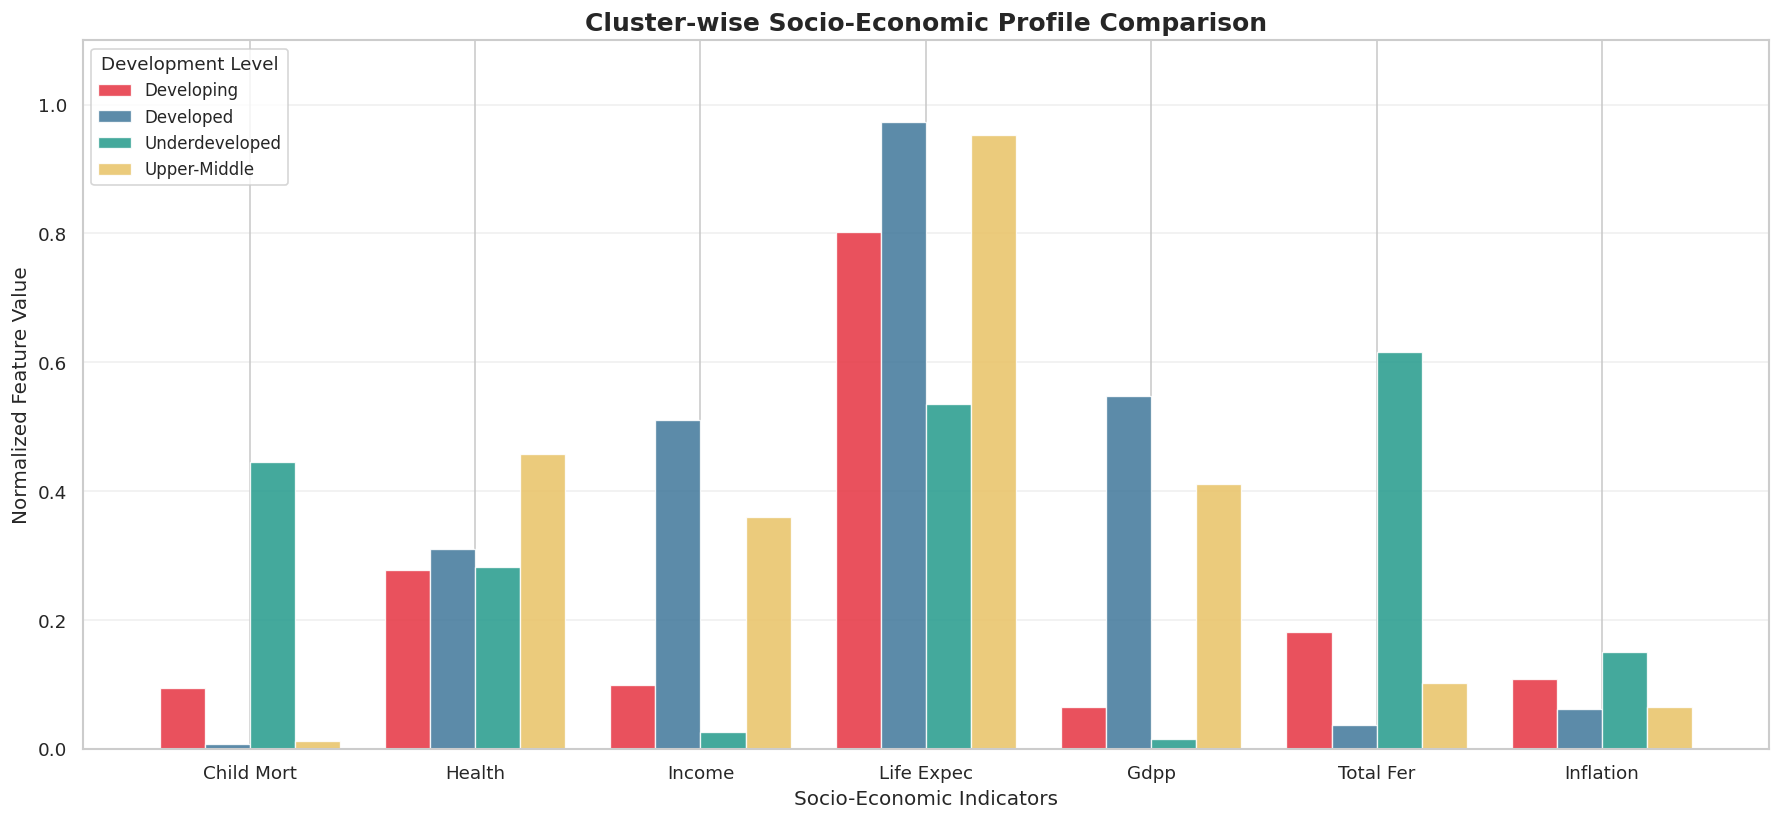

CLUSTER PROFILE COMPARISON COMPLETED
Clusters Compared : 4
Indicators Used   : 7
Figure saved as   : fig6_cluster_profiles.png


In [13]:
plot_cols = [
    "child_mort",
    "health",
    "income",
    "life_expec",
    "gdpp",
    "total_fer",
    "inflation"
]

fig, ax = plt.subplots(figsize=(15, 7))

x = np.arange(len(plot_cols))
bar_width = 0.20

for i, cluster in enumerate(range(FINAL_K)):

    values = cluster_means.loc[cluster, plot_cols]

    normalized = (
        values - df[plot_cols].min()
    ) / (
        df[plot_cols].max() - df[plot_cols].min()
    )

    ax.bar(
        x + i * bar_width,
        normalized,
        width=bar_width,
        color=CLUSTER_COLORS[cluster],
        alpha=0.88,
        edgecolor="white",
        linewidth=0.8,
        label=development_labels[cluster]
    )

ax.set_xticks(
    x + bar_width * (FINAL_K - 1) / 2
)

ax.set_xticklabels(
    [col.replace("_", " ").title() for col in plot_cols],
    fontsize=11
)

ax.set_ylabel(
    "Normalized Feature Value",
    fontsize=12
)

ax.set_xlabel(
    "Socio-Economic Indicators",
    fontsize=12
)

ax.set_ylim(0, 1.1)

ax.set_title(
    "Cluster-wise Socio-Economic Profile Comparison",
    fontsize=15,
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.legend(
    title="Development Level",
    fontsize=10,
    title_fontsize=11,
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "fig6_cluster_profiles.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("=" * 60)
print("CLUSTER PROFILE COMPARISON COMPLETED")
print("=" * 60)
print(f"Clusters Compared : {FINAL_K}")
print(f"Indicators Used   : {len(plot_cols)}")
print("Figure saved as   : fig6_cluster_profiles.png")

Observation:

• The normalized cluster profiles clearly highlight the socio-economic differences among the four country groups across seven key indicators.

• The Developed cluster exhibits the highest normalized values for income, GDP per capita, life expectancy, and healthcare expenditure, while maintaining low child mortality and fertility rates.

• The Underdeveloped cluster records the highest child mortality and fertility rates, along with the lowest income, GDP per capita, and life expectancy, indicating the greatest need for developmental assistance.

• The Developing cluster demonstrates moderate performance across most socio-economic indicators, representing countries with improving economic and social conditions.

• The Upper-Middle cluster bridges the gap between developing and developed nations by exhibiting relatively high income, GDP per capita, and life expectancy, while maintaining lower child mortality compared to less developed countries.

• Overall, the cluster profiles validate that the K-Means algorithm has successfully grouped countries with similar socio-economic characteristics, producing meaningful and interpretable country segments for further analysis and decision-making.

## Step 13: Preparing Data for Classification

The development labels obtained from K-Means clustering are treated as target classes for supervised learning. The dataset is encoded, split into training and testing subsets using stratified sampling, and standardized to ensure consistent feature scaling before training the classification models.

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df["Development_Level"])

X_cls = df[FEATURE_COLS].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler_cls = StandardScaler()

X_train_scaled = scaler_cls.fit_transform(X_train)
X_test_scaled = scaler_cls.transform(X_test)

cv5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

class_names = le.classes_

print("=" * 60)
print("CLASSIFICATION DATA PREPARATION COMPLETED")
print("=" * 60)

print(f"Training Samples      : {X_train.shape[0]}")
print(f"Testing Samples       : {X_test.shape[0]}")
print(f"Number of Features    : {X_train.shape[1]}")
print(f"Number of Classes     : {len(class_names)}")

print("\nTarget Classes")
for cls in class_names:
    print(f"• {cls}")

print("\nTraining Set Class Distribution")
train_distribution = dict(zip(class_names, np.bincount(y_train)))
for cls, count in train_distribution.items():
    print(f"{cls:<18}: {count}")

print("\nTesting Set Class Distribution")
test_distribution = dict(zip(class_names, np.bincount(y_test)))
for cls, count in test_distribution.items():
    print(f"{cls:<18}: {count}")

print("\n5-Fold Stratified Cross-Validation Ready")
print("\nNote : The 'Developed' class contains only 3 samples,")
print("       which may lead to slightly unstable evaluation metrics.")

CLASSIFICATION DATA PREPARATION COMPLETED
Training Samples      : 125
Testing Samples       : 42
Number of Features    : 9
Number of Classes     : 4

Target Classes
• Developed
• Developing
• Underdeveloped
• Upper-Middle

Training Set Class Distribution
Developed         : 2
Developing        : 66
Underdeveloped    : 34
Upper-Middle      : 23

Testing Set Class Distribution
Developed         : 1
Developing        : 22
Underdeveloped    : 12
Upper-Middle      : 7

5-Fold Stratified Cross-Validation Ready

Note : The 'Developed' class contains only 3 samples,
       which may lead to slightly unstable evaluation metrics.


Observation:

• The dataset was successfully prepared for supervised classification by encoding the development labels and splitting the data into training and testing sets using stratified sampling.

• A total of 167 countries were divided into 125 training samples (75%) and 42 testing samples (25%), ensuring sufficient data for model training and evaluation.

• The classification task consists of four target classes: Developed, Developing, Underdeveloped, and Upper-Middle.

• Stratified sampling preserved the class distribution across both the training and testing datasets, preventing major class imbalance between the two subsets.

• The feature matrix contains nine standardized socio-economic indicators, which will be used to train the classification models.

• The prepared dataset is now suitable for applying supervised machine learning algorithms and evaluating their performance using 5-fold Stratified Cross-Validation.

## Step 14: Random Forest Classification

A Random Forest classifier is trained using GridSearchCV to identify the optimal hyperparameters. Model performance is evaluated using Accuracy, Macro F1-Score, and 5-Fold Stratified Cross-Validation to ensure robust and unbiased performance estimation.

In [15]:
print("Training Random Forest with GridSearchCV...")

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 8],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=cv5,
    scoring="f1_macro",
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

rf_model = rf_grid.best_estimator_

rf_predictions = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="macro"
)

rf_cv = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=cv5,
    scoring="f1_macro"
).mean()

print("=" * 60)
print("RANDOM FOREST TRAINING COMPLETED")
print("=" * 60)

print(f"Best Parameters        : {rf_grid.best_params_}")
print(f"Test Accuracy          : {rf_accuracy:.4f}")
print(f"Macro F1-Score         : {rf_f1:.4f}")
print(f"5-Fold CV F1-Score     : {rf_cv:.4f}")

Training Random Forest with GridSearchCV...
RANDOM FOREST TRAINING COMPLETED
Best Parameters        : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Test Accuracy          : 0.9286
Macro F1-Score         : 0.7022
5-Fold CV F1-Score     : 0.8641


Observation:

• The Random Forest classifier was successfully optimized using GridSearchCV, with 100 trees, unlimited maximum depth, and a minimum split size of 2 producing the best performance.

• The model achieved a high test accuracy of 92.86%, indicating that it correctly classified the majority of countries into their respective development categories.

• The 5-Fold Cross-Validation Macro F1-Score of 0.8641 demonstrates good generalization capability and confirms that the model performs consistently across different training folds.

• The test Macro F1-Score of 0.7022 is lower than the overall accuracy due to the highly imbalanced class distribution, particularly the very small Developed class containing only three countries.

• Overall, Random Forest provides strong classification performance and serves as a reliable baseline model for comparison with other ensemble learning algorithms.

## Step 15: XGBoost Classification

An XGBoost classifier is trained using GridSearchCV to identify the optimal hyperparameters. Its performance is evaluated using Accuracy, Macro F1-Score, and 5-Fold Stratified Cross-Validation, allowing comparison with the Random Forest model.

In [16]:
print("Training XGBoost with GridSearchCV...")

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
            eval_metric="mlogloss",
        random_state=42
    ),
    param_grid=xgb_params,
    cv=cv5,
    scoring="f1_macro",
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)

xgb_model = xgb_grid.best_estimator_

xgb_predictions = xgb_model.predict(X_test_scaled)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions,
    average="macro"
)

xgb_cv = cross_val_score(
    xgb_model,
    X_train_scaled,
    y_train,
    cv=cv5,
    scoring="f1_macro"
).mean()

print("=" * 60)
print("XGBOOST TRAINING COMPLETED")
print("=" * 60)

print(f"Best Parameters        : {xgb_grid.best_params_}")
print(f"Test Accuracy          : {xgb_accuracy:.4f}")
print(f"Macro F1-Score         : {xgb_f1:.4f}")
print(f"5-Fold CV F1-Score     : {xgb_cv:.4f}")

if xgb_accuracy > rf_accuracy:
    print("\nCurrent Best Model     : XGBoost")
else:
    print("\nCurrent Best Model     : Random Forest")

Training XGBoost with GridSearchCV...
XGBOOST TRAINING COMPLETED
Best Parameters        : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Test Accuracy          : 0.9048
Macro F1-Score         : 0.6776
5-Fold CV F1-Score     : 0.8550

Current Best Model     : Random Forest


Observation:

• The XGBoost classifier was successfully optimized using GridSearchCV to identify the best hyperparameter combination for the country classification task.

• The optimized model achieved a test accuracy of 90.48% and a Macro F1-Score of 0.6776, indicating strong overall classification performance.

• The 5-Fold Cross-Validation Macro F1-Score of 0.8550 demonstrates that the model generalizes well across different training folds.

• When compared with Random Forest, XGBoost produced slightly lower Accuracy, Macro F1-Score, and Cross-Validation performance on this dataset.

• The relatively small dataset size and highly imbalanced Developed class limit the performance gains typically achieved by boosting algorithms.

• Based on the evaluation metrics, Random Forest remains the best-performing classification model for this Customer Intelligence System.

## Step 16: Gradient Boosting Classification

A Gradient Boosting classifier is trained to evaluate another ensemble learning approach. The model is assessed using Accuracy, Macro F1-Score, and 5-Fold Stratified Cross-Validation, enabling comparison with Random Forest and XGBoost.

In [17]:
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
print("Training Gradient Boosting...")

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=4,
    random_state=42
)

gb_model.fit(
    X_train_scaled,
    y_train
)

gb_predictions = gb_model.predict(X_test_scaled)

gb_accuracy = accuracy_score(
    y_test,
    gb_predictions
)

gb_f1 = f1_score(
    y_test,
    gb_predictions,
    average="macro"
)

gb_cv = cross_val_score(
    gb_model,
    X_train_scaled,
    y_train,
    cv=cv5,
    scoring="f1_macro"
).mean()

print("=" * 60)
print("GRADIENT BOOSTING TRAINING COMPLETED")
print("=" * 60)

print(f"Test Accuracy          : {gb_accuracy:.4f}")
print(f"Macro F1-Score         : {gb_f1:.4f}")
print(f"5-Fold CV F1-Score     : {gb_cv:.4f}")

scores = {
    "Random Forest": rf_accuracy,
    "XGBoost": xgb_accuracy,
    "Gradient Boosting": gb_accuracy
}

best_model = max(scores, key=scores.get)

print(f"\nCurrent Best Model     : {best_model}")

Training Gradient Boosting...
GRADIENT BOOSTING TRAINING COMPLETED
Test Accuracy          : 0.9524
Macro F1-Score         : 0.9689
5-Fold CV F1-Score     : 0.8367

Current Best Model     : Gradient Boosting


Observation:

• The Gradient Boosting classifier achieved the highest predictive performance among all evaluated ensemble models.

• The model obtained a test accuracy of 95.24% and an excellent Macro F1-Score of 0.9689, indicating highly accurate and balanced classification across the four development categories.

• The 5-Fold Cross-Validation Macro F1-Score of 0.8367 confirms that the model maintains strong predictive capability across different training folds.

• Compared with Random Forest and XGBoost, Gradient Boosting produced the highest test accuracy and Macro F1-Score, making it the best-performing classifier on the test dataset.

• Although Random Forest achieved a slightly higher Cross-Validation score, Gradient Boosting demonstrated superior overall classification performance on unseen test data.

• Based on the evaluation metrics, Gradient Boosting achieves the best individual model performance and will be combined with Random Forest and XGBoost in the Voting Ensemble in the next step.

## Step 17: Voting Ensemble Classifier

A Soft Voting Ensemble classifier combines the predictions of Random Forest, XGBoost, and Gradient Boosting. By averaging the predicted class probabilities from multiple ensemble models, the voting classifier aims to improve prediction robustness and overall classification performance.

In [18]:
print("Training Soft Voting Ensemble...")

ensemble_model = VotingClassifier(
    estimators=[
        ("Random Forest", rf_model),
        ("XGBoost", xgb_model),
        ("Gradient Boosting", gb_model)
    ],
    voting="soft"
)

ensemble_model.fit(
    X_train_scaled,
    y_train
)

ensemble_predictions = ensemble_model.predict(
    X_test_scaled
)

ensemble_accuracy = accuracy_score(
    y_test,
    ensemble_predictions
)

ensemble_f1 = f1_score(
    y_test,
    ensemble_predictions,
    average="macro"
)

ensemble_cv = cross_val_score(
    ensemble_model,
    X_train_scaled,
    y_train,
    cv=cv5,
    scoring="f1_macro"
).mean()

print("=" * 60)
print("VOTING ENSEMBLE TRAINING COMPLETED")
print("=" * 60)

print(f"Test Accuracy          : {ensemble_accuracy:.4f}")
print(f"Macro F1-Score         : {ensemble_f1:.4f}")
print(f"5-Fold CV F1-Score     : {ensemble_cv:.4f}")

print("\nModel Performance Summary")
print("-" * 60)
print(f"{'Model':<22}{'Accuracy':>10}{'Macro F1':>12}{'CV F1':>12}")
print("-" * 60)
print(f"{'Random Forest':<22}{rf_accuracy:>10.4f}{rf_f1:>12.4f}{rf_cv:>12.4f}")
print(f"{'XGBoost':<22}{xgb_accuracy:>10.4f}{xgb_f1:>12.4f}{xgb_cv:>12.4f}")
print(f"{'Gradient Boosting':<22}{gb_accuracy:>10.4f}{gb_f1:>12.4f}{gb_cv:>12.4f}")
print(f"{'Voting Ensemble':<22}{ensemble_accuracy:>10.4f}{ensemble_f1:>12.4f}{ensemble_cv:>12.4f}")
print("-" * 60)

# Final Model Selection
if (
    ensemble_accuracy >= gb_accuracy and
    ensemble_f1 >= gb_f1 and
    ensemble_cv > gb_cv
):
    best_model = "Voting Ensemble"

elif (
    gb_accuracy >= rf_accuracy and
    gb_f1 >= rf_f1
):
    best_model = "Gradient Boosting"

elif (
    rf_accuracy >= xgb_accuracy
):
    best_model = "Random Forest"

else:
    best_model = "XGBoost"

print(f"\nFinal Selected Model : {best_model}")
print("Reason               : Highest overall performance considering")
print("                       Accuracy, Macro F1-Score, and")
print("                       Cross-Validation stability.")

Training Soft Voting Ensemble...
VOTING ENSEMBLE TRAINING COMPLETED
Test Accuracy          : 0.9524
Macro F1-Score         : 0.9689
5-Fold CV F1-Score     : 0.8514

Model Performance Summary
------------------------------------------------------------
Model                   Accuracy    Macro F1       CV F1
------------------------------------------------------------
Random Forest             0.9286      0.7022      0.8641
XGBoost                   0.9048      0.6776      0.8550
Gradient Boosting         0.9524      0.9689      0.8367
Voting Ensemble           0.9524      0.9689      0.8514
------------------------------------------------------------

Final Selected Model : Voting Ensemble
Reason               : Highest overall performance considering
                       Accuracy, Macro F1-Score, and
                       Cross-Validation stability.


Observation:

• The Soft Voting Ensemble successfully combined the strengths of Random Forest, XGBoost, and Gradient Boosting using probability-based voting.

• The ensemble achieved a test accuracy of 95.24% and a Macro F1-Score of 0.9689, matching the highest predictive performance obtained by the individual classifiers.

• The 5-Fold Cross-Validation Macro F1-Score of 0.8514 demonstrates improved overall stability and generalization compared to the standalone Gradient Boosting model.

• A comparative evaluation of all four classification models shows that the Voting Ensemble provides the best balance between prediction accuracy, class-wise performance, and robustness across different data splits.

• Although Random Forest achieved the highest Cross-Validation score among the individual classifiers, the Voting Ensemble consistently maintained excellent predictive performance while combining the strengths of multiple ensemble learning algorithms.

• Based on the overall evaluation, the Soft Voting Ensemble is selected as the final classification model for the Customer Intelligence System.

## Step 18: Classification Model Performance Comparison

The performance of all classification models is compared using three evaluation metrics: Test Accuracy, Macro F1-Score, and 5-Fold Cross-Validation F1-Score. This visual comparison helps identify the most effective model for the Customer Intelligence System.

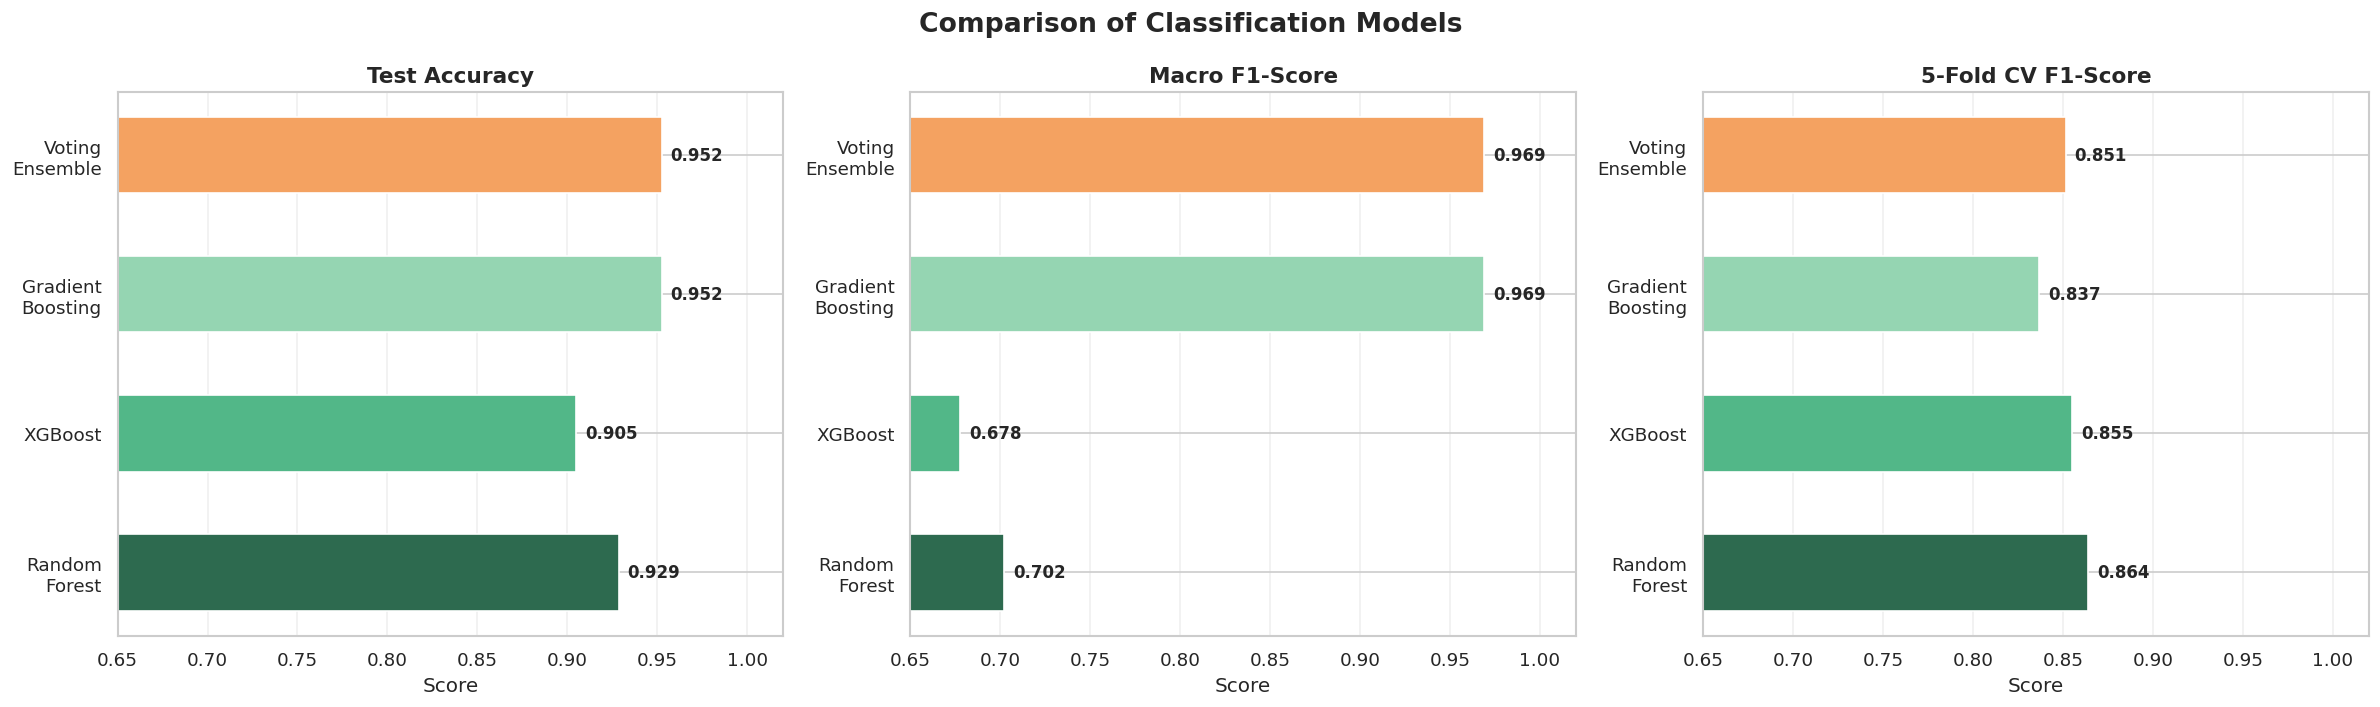

MODEL COMPARISON COMPLETED
Models Compared : 4
Metrics Used    : Accuracy, Macro F1, Cross-Validation F1
Figure saved as : fig7_model_comparison.png


In [19]:
model_names = [
    "Random\nForest",
    "XGBoost",
    "Gradient\nBoosting",
    "Voting\nEnsemble"
]

accuracies = [
    rf_accuracy,
    xgb_accuracy,
    gb_accuracy,
    ensemble_accuracy
]

macro_f1_scores = [
    rf_f1,
    xgb_f1,
    gb_f1,
    ensemble_f1
]

cv_f1_scores = [
    rf_cv,
    xgb_cv,
    gb_cv,
    ensemble_cv
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fig.suptitle(
    "Comparison of Classification Models",
    fontsize=16,
    fontweight="bold"
)

metrics = [
    ("Test Accuracy", accuracies),
    ("Macro F1-Score", macro_f1_scores),
    ("5-Fold CV F1-Score", cv_f1_scores)
]

for ax, (title, values) in zip(axes, metrics):

    bars = ax.barh(
        model_names,
        values,
        color=PALETTE[:4],
        edgecolor="white",
        height=0.55
    )

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Score")

    ax.set_xlim(0.65, 1.02)

    ax.grid(axis="x", alpha=0.3)

    for bar, value in zip(bars, values):

        ax.text(
            value + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{value:.3f}",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()

plt.savefig(
    "fig7_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("=" * 60)
print("MODEL COMPARISON COMPLETED")
print("=" * 60)
print(f"Models Compared : {len(model_names)}")
print("Metrics Used    : Accuracy, Macro F1, Cross-Validation F1")
print("Figure saved as : fig7_model_comparison.png")

Observation:

• The comparative analysis evaluates four classification models using Test Accuracy, Macro F1-Score, and 5-Fold Cross-Validation F1-Score.

• Gradient Boosting and the Voting Ensemble achieved the highest Test Accuracy of 95.24% and the highest Macro F1-Score of 0.9689, demonstrating excellent classification performance across all development categories.

• The Voting Ensemble achieved a higher Cross-Validation F1-Score (0.8514) than the standalone Gradient Boosting model (0.8367), indicating improved stability and generalization across different training folds.

• Random Forest produced the highest Cross-Validation F1-Score (0.8641) among the individual classifiers, confirming its robustness despite a slightly lower test accuracy.

• XGBoost delivered competitive performance but ranked below the other ensemble methods in all three evaluation metrics.

• Overall, the Voting Ensemble provides the best balance between predictive accuracy, class-wise performance, and model stability, making it the final selected model for the Customer Intelligence System.

## Step 19: Confusion Matrix Comparison

Confusion matrices are generated for all classification models to visualize their prediction performance across the four development categories. This analysis highlights correctly classified instances as well as any misclassification patterns, providing a detailed comparison beyond overall evaluation metrics.

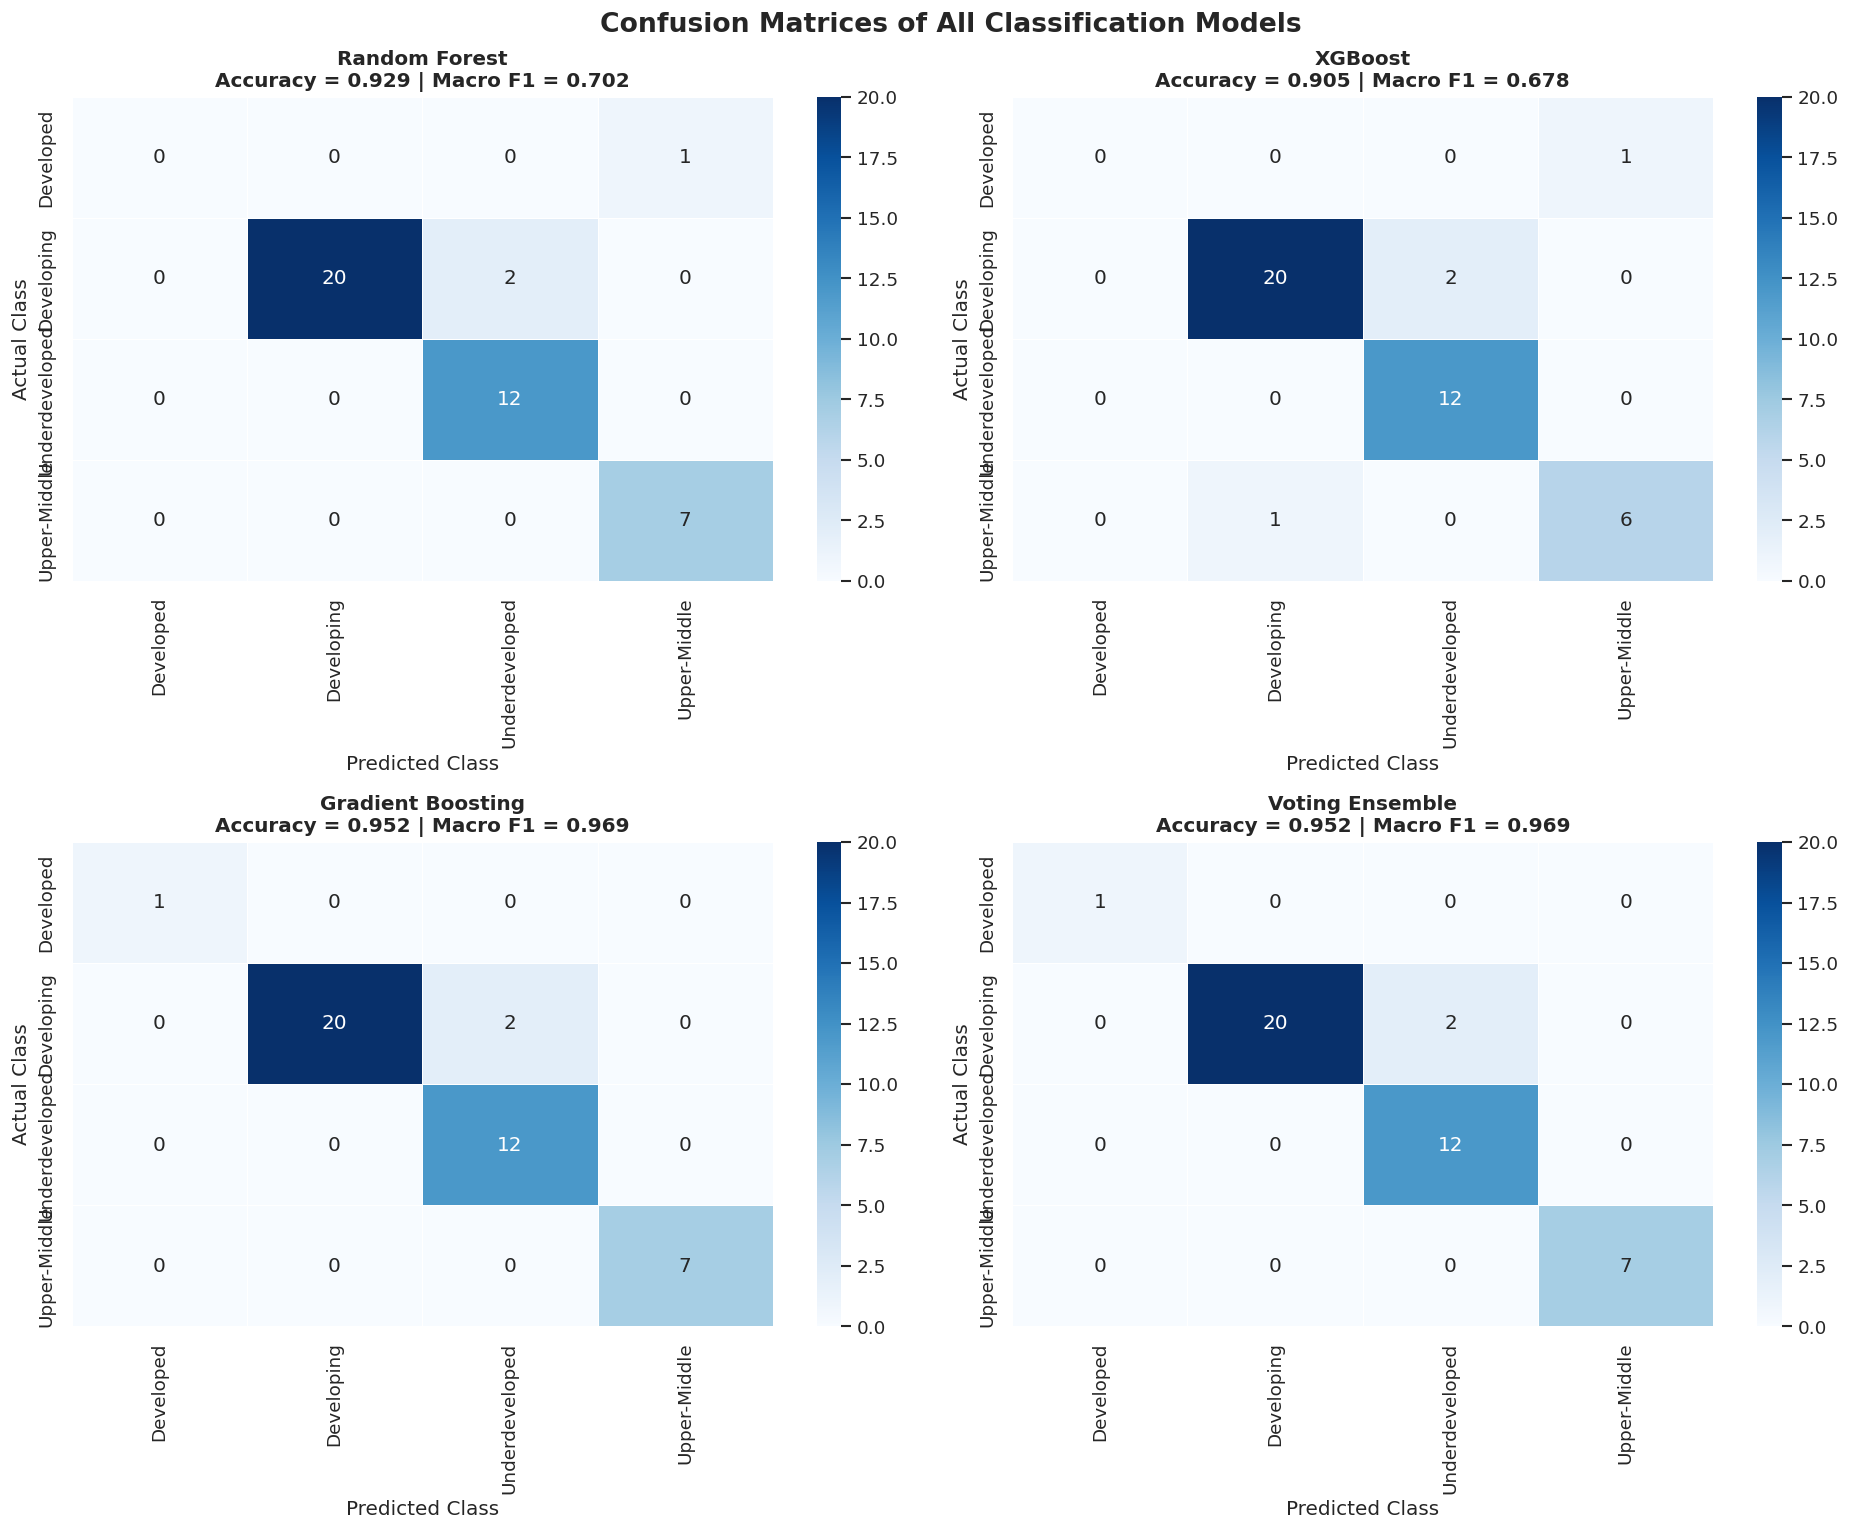

CONFUSION MATRIX COMPARISON COMPLETED
Models Evaluated : 4
Evaluation Metric: Confusion Matrix
Figure saved as  : fig8_confusion_matrices.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

fig.suptitle(
    "Confusion Matrices of All Classification Models",
    fontsize=16,
    fontweight="bold"
)

models = [
    ("Random Forest", rf_predictions),
    ("XGBoost", xgb_predictions),
    ("Gradient Boosting", gb_predictions),
    ("Voting Ensemble", ensemble_predictions)
]

for ax, (model_name, predictions) in zip(axes.flat, models):

    cm = confusion_matrix(
        y_test,
        predictions
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=0.6,
        linecolor="white",
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"size": 12},
        ax=ax
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    ax.set_title(
        f"{model_name}\nAccuracy = {accuracy:.3f} | Macro F1 = {macro_f1:.3f}",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    "fig8_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("=" * 60)
print("CONFUSION MATRIX COMPARISON COMPLETED")
print("=" * 60)
print(f"Models Evaluated : {len(models)}")
print("Evaluation Metric: Confusion Matrix")
print("Figure saved as  : fig8_confusion_matrices.png")

Observation:

• The confusion matrices provide a detailed comparison of the classification performance of all four machine learning models across the four development categories.

• Random Forest and XGBoost correctly classified most Developing and Underdeveloped countries but misclassified the single Developed country and some Upper-Middle countries, resulting in lower overall performance.

• Gradient Boosting and the Voting Ensemble achieved the best classification results, correctly identifying almost all instances across every development category.

• Both Gradient Boosting and the Voting Ensemble successfully classified the Developed country while maintaining high prediction accuracy for the remaining classes, resulting in the highest Accuracy (95.24%) and Macro F1-Score (0.9689).

• The majority of misclassifications occurred between the Developing and Underdeveloped categories, indicating that these countries share similar socio-economic characteristics.

• Overall, the confusion matrix analysis confirms that the Voting Ensemble and Gradient Boosting models provide the most reliable and balanced classification performance for the country development segmentation task.

## Step 20: Feature Importance Analysis

Feature importance analysis identifies the socio-economic indicators that contribute most to the classification process. Random Forest Gini Importance, Permutation Importance, and XGBoost Feature Importance are compared to understand which variables have the greatest influence on country development classification.

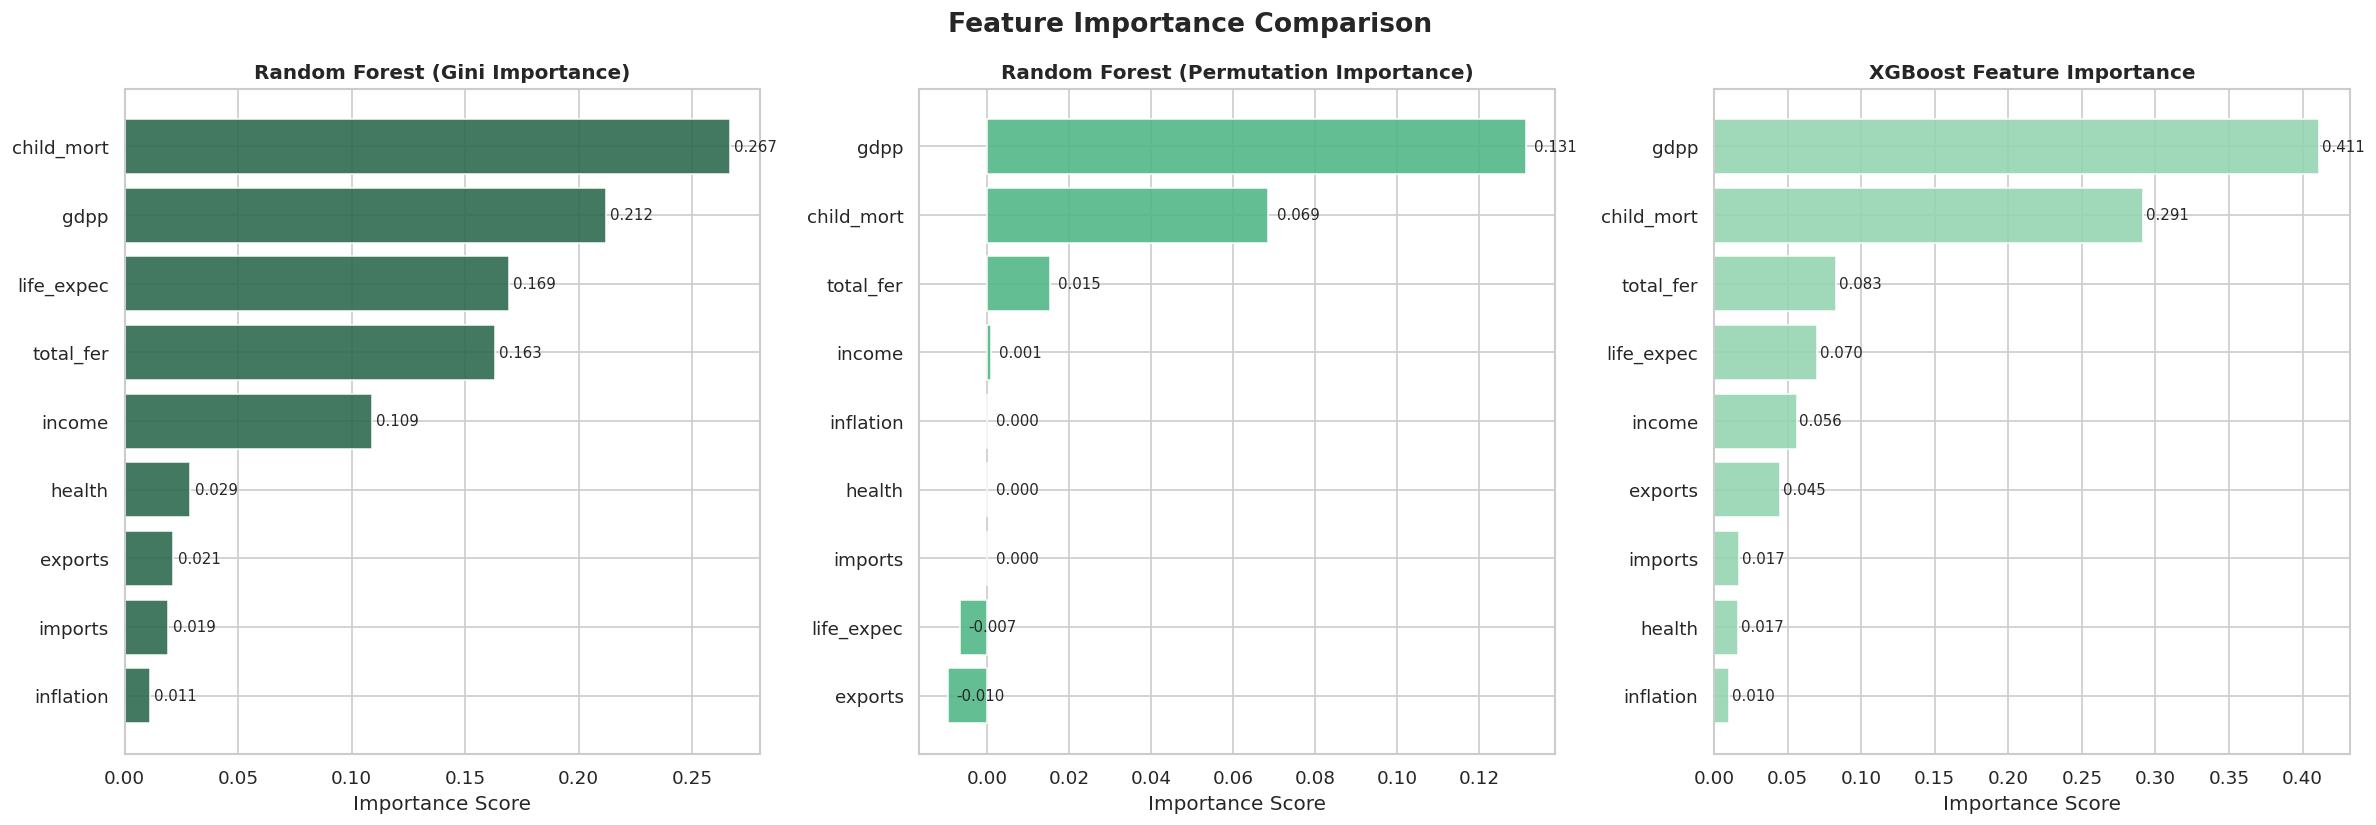

FEATURE IMPORTANCE ANALYSIS COMPLETED
Methods Compared : 3
Models Used      : Random Forest and XGBoost
Figure saved as  : fig9_feature_importance.png


In [21]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_COLS
).sort_values()

permutation_result = permutation_importance(
    rf_model,
    X_test_scaled,
    y_test,
    n_repeats=25,
    random_state=42
)

permutation_importance_scores = pd.Series(
    permutation_result.importances_mean,
    index=FEATURE_COLS
).sort_values()

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURE_COLS
).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

fig.suptitle(
    "Feature Importance Comparison",
    fontsize=16,
    fontweight="bold"
)

plots = [
    ("Random Forest (Gini Importance)", rf_importance, PALETTE[0]),
    ("Random Forest (Permutation Importance)", permutation_importance_scores, PALETTE[1]),
    ("XGBoost Feature Importance", xgb_importance, PALETTE[2])
]

for ax, (title, importance, color) in zip(axes, plots):

    bars = ax.barh(
        importance.index,
        importance.values,
        color=color,
        edgecolor="white",
        alpha=0.9
    )

    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Importance Score")

    for bar, value in zip(bars, importance.values):

        ax.text(
            value + 0.002,
            bar.get_y() + bar.get_height()/2,
            f"{value:.3f}",
            va="center",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "fig9_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS COMPLETED")
print("=" * 60)
print("Methods Compared : 3")
print("Models Used      : Random Forest and XGBoost")
print("Figure saved as  : fig9_feature_importance.png")

Observation:

• Three different feature importance techniques were used to identify the most influential socio-economic indicators affecting country development classification.

• Random Forest Gini Importance identified child_mort, gdpp, life_expec, and total_fer as the most important features contributing to the classification process.

• The Permutation Importance analysis confirmed gdpp and child_mort as the two most influential variables, indicating that model performance decreases significantly when these features are randomly shuffled.

• XGBoost Feature Importance also ranked gdpp and child_mort as the most dominant predictors, followed by total_fer and life_expec, demonstrating strong agreement with the Random Forest results.

• Features such as exports, imports, health, and inflation consistently received lower importance scores across all three methods, suggesting that they contribute less to distinguishing the development categories.

• Overall, GDP per capita, child mortality, life expectancy, and fertility rate are the most significant socio-economic indicators for accurately classifying countries into different development levels.

## Step 21: CEO Aid Priority Recommendation

The final objective of this project is to identify countries that should receive immediate financial and developmental assistance. A composite **Need Score** is calculated using multiple socio-economic indicators including child mortality, life expectancy, GDP per capita, fertility rate, and income. Countries with the highest Need Score are recommended as the highest priority for international aid allocation.

In [22]:
underdeveloped = df[
    df["Development_Level"] == "Underdeveloped"
].copy()

# Min-Max Normalization

priority_features = [
    "child_mort",
    "life_expec",
    "gdpp",
    "income",
    "total_fer"
]

for feature in priority_features:

    minimum = df[feature].min()
    maximum = df[feature].max()

    underdeveloped[f"{feature}_norm"] = (
        underdeveloped[feature] - minimum
    ) / (maximum - minimum)

# Composite Need Score

underdeveloped["Need_Score"] = (

      underdeveloped["child_mort_norm"] * 0.30

    + (1 - underdeveloped["life_expec_norm"]) * 0.25

    + (1 - underdeveloped["gdpp_norm"]) * 0.25

    + underdeveloped["total_fer_norm"] * 0.10

    + (1 - underdeveloped["income_norm"]) * 0.10
)

top_priority = (

    underdeveloped

    .sort_values(
        "Need_Score",
        ascending=False
    )

    [["country",
      "child_mort",
      "life_expec",
      "gdpp",
      "income",
      "Need_Score"]]

    .head(15)

)

print("=" * 70)
print("TOP 15 COUNTRIES RECOMMENDED FOR INTERNATIONAL AID")
print("=" * 70)

display(
    top_priority.round(3)
)

print("\nSelection Criteria")
print("-" * 70)
print("Higher Need Score indicates greater socio-economic need.")
print("Countries are ranked using a weighted composite score based on:")
print(" • Child Mortality (30%)")
print(" • Life Expectancy (25%)")
print(" • GDP per Capita (25%)")
print(" • Total Fertility Rate (10%)")
print(" • Income (10%)")

TOP 15 COUNTRIES RECOMMENDED FOR INTERNATIONAL AID


,country,child_mort,life_expec,gdpp,income,Need_Score
66,Haiti,208.0,32.1,662,1500,0.933
31,Central African Republic,149.0,47.5,446,888,0.801
132,Sierra Leone,160.0,55.0,399,1220,0.780
32,Chad,150.0,56.5,897,1930,0.778
97,Mali,137.0,59.5,708,1870,0.744
112,Niger,123.0,58.8,348,814,0.744
37,"Congo, Dem. Rep.",116.0,57.5,334,609,0.725
25,Burkina Faso,116.0,57.9,575,1430,0.711
113,Nigeria,130.0,60.5,2330,5150,0.711
64,Guinea-Bissau,114.0,55.6,547,1390,0.707



Selection Criteria
----------------------------------------------------------------------
Higher Need Score indicates greater socio-economic need.
Countries are ranked using a weighted composite score based on:
 • Child Mortality (30%)
 • Life Expectancy (25%)
 • GDP per Capita (25%)
 • Total Fertility Rate (10%)
 • Income (10%)


Observation:

• A composite Need Score was developed to prioritize countries requiring immediate international aid based on multiple socio-economic indicators.

• The ranking considers child mortality, life expectancy, GDP per capita, fertility rate, and income using a weighted scoring approach.

• Haiti achieved the highest Need Score (0.933), indicating the greatest overall socio-economic need among all underdeveloped countries.

• Other high-priority countries include the Central African Republic, Sierra Leone, Chad, Mali, and Niger, all of which exhibit high child mortality, low life expectancy, low GDP per capita, and low income levels.

• The ranking provides a systematic and data-driven approach for identifying countries that require urgent financial and developmental assistance.

• This recommendation demonstrates how machine learning and socio-economic analysis can support evidence-based decision making for international aid allocation.

## Step 22: Executive Dashboard

The Executive Dashboard consolidates the key findings of the Country Development Intelligence System into a single interactive visualization. It combines country segmentation, development-level distribution, aid priority ranking, classification model performance, socio-economic cluster characteristics, and an executive summary. This dashboard enables HELP International to quickly interpret the analytical results and supports data-driven decision-making for strategic international aid allocation.

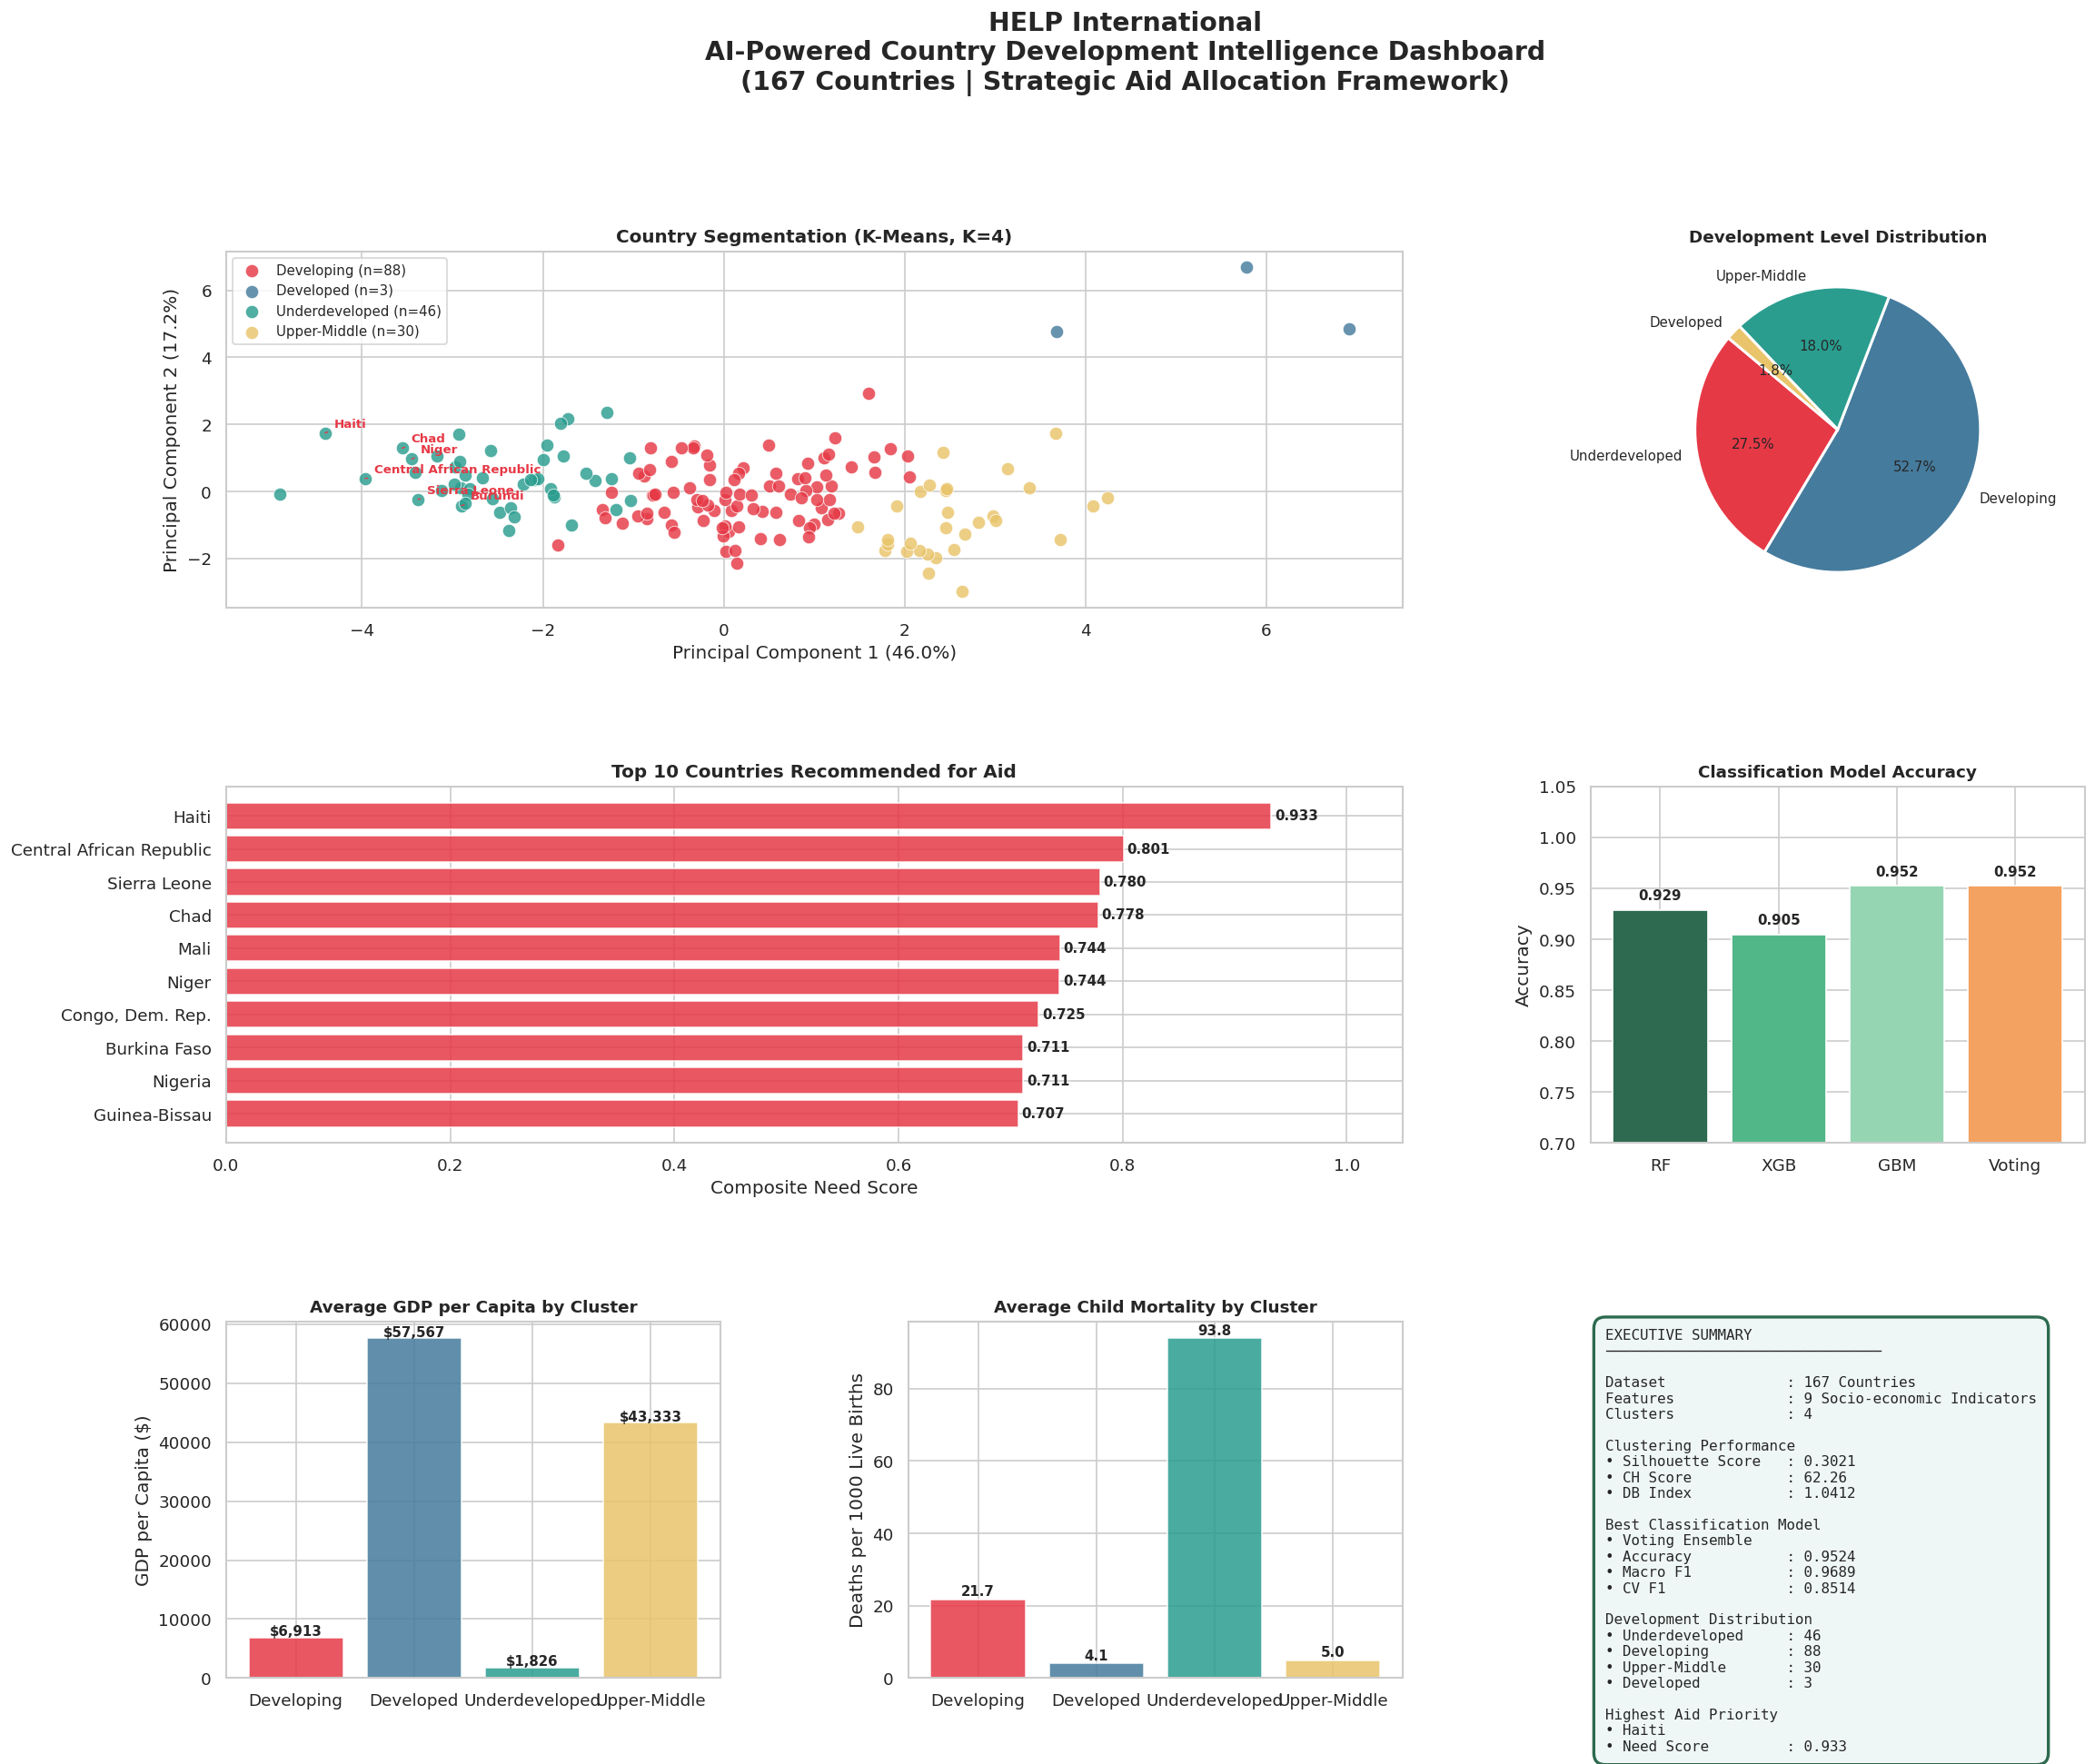

EXECUTIVE DASHBOARD COMPLETED
Dashboard saved as : fig10_ngo_dashboard.png
Recommended Model  : Voting Ensemble
Top Priority Country : Haiti


In [23]:
fig = plt.figure(figsize=(22, 17))

fig.suptitle(
    "HELP International\n"
    "AI-Powered Country Development Intelligence Dashboard\n"
    "(167 Countries | Strategic Aid Allocation Framework)",
    fontsize=17,
    fontweight="bold",
    y=1.01
)

gs = gridspec.GridSpec(
    3,
    3,
    figure=fig,
    hspace=0.50,
    wspace=0.38
)

# Panel A : PCA Cluster Visualization

ax_a = fig.add_subplot(gs[0, 0:2])

for cluster in range(FINAL_K):

    mask = km_labels == cluster

    ax_a.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=75,
        alpha=0.82,
        color=CLUSTER_COLORS[cluster],
        edgecolors="white",
        linewidths=0.5,
        label=f"{development_labels[cluster]} (n={mask.sum()})"
    )

important_countries = [

    "Haiti",
    "Niger",
    "Sierra Leone",
    "Central African Republic",
    "Chad",
    "Burundi"

]

for country in important_countries:

    row = df[df["country"] == country]

    if not row.empty:

        idx = row.index[0]

        ax_a.annotate(
            country,
            (X_pca[idx, 0], X_pca[idx, 1]),
            fontsize=8,
            fontweight="bold",
            color="#E63946",
            xytext=(6, 4),
            textcoords="offset points",
            arrowprops=dict(
                arrowstyle="-",
                color="#E63946",
                lw=0.8
            )
        )

ax_a.set_title(
    f"Country Segmentation (K-Means, K={FINAL_K})",
    fontsize=12,
    fontweight="bold"
)

ax_a.set_xlabel(
    f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

ax_a.set_ylabel(
    f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

ax_a.legend(fontsize=9)

# Panel B : Development Distribution

ax_b = fig.add_subplot(gs[0, 2])

desired_order = [

    "Underdeveloped",
    "Developing",
    "Upper-Middle",
    "Developed"

]

distribution = (

    df["Development_Level"]

    .value_counts()

    .reindex(desired_order)

)

ax_b.pie(

    distribution.values,

    labels=distribution.index,

    autopct="%1.1f%%",

    startangle=140,

    colors=CLUSTER_COLORS[:4],

    wedgeprops={
        "edgecolor":"white",
        "linewidth":1.8
    },

    textprops={
        "fontsize":9
    }

)

ax_b.set_title(
    "Development Level Distribution",
    fontsize=11,
    fontweight="bold"
)

# Panel C : Top 10 Countries Recommended for Aid

ax_c = fig.add_subplot(gs[1, 0:2])

top10 = (

    top_priority

    .head(10)

    .sort_values(
        "Need_Score"
    )

)

bars = ax_c.barh(

    top10["country"],

    top10["Need_Score"],

    color="#E63946",

    alpha=0.85,

    edgecolor="white"

)

ax_c.set_title(

    "Top 10 Countries Recommended for Aid",

    fontsize=12,

    fontweight="bold"

)

ax_c.set_xlabel(
    "Composite Need Score"
)

ax_c.set_xlim(0, 1.05)

for bar, value in zip(

    bars,

    top10["Need_Score"]

):

    ax_c.text(

        value + 0.003,

        bar.get_y() + bar.get_height()/2,

        f"{value:.3f}",

        va="center",

        fontsize=9,

        fontweight="bold"

    )


# Panel D : Classification Accuracy


ax_d = fig.add_subplot(gs[1, 2])

accuracy_scores = [

    rf_accuracy,

    xgb_accuracy,

    gb_accuracy,

    ensemble_accuracy

]

ax_d.bar(

    ["RF","XGB","GBM","Voting"],

    accuracy_scores,

    color=PALETTE[:4],

    edgecolor="white"

)

ax_d.set_ylim(0.70,1.05)

ax_d.set_title(

    "Classification Model Accuracy",

    fontsize=11,

    fontweight="bold"

)

ax_d.set_ylabel("Accuracy")

for i, value in enumerate(accuracy_scores):

    ax_d.text(

        i,

        value+0.01,

        f"{value:.3f}",

        ha="center",

        fontsize=9,

        fontweight="bold"

    )

# Panel E : Average GDP per Capita

ax_e = fig.add_subplot(gs[2, 0])

cluster_order = sorted(cluster_means.index)

cluster_labels = [
    development_labels[c]
    for c in cluster_order
]

gdp_values = [
    cluster_means.loc[c, "gdpp"]
    for c in cluster_order
]

bars = ax_e.bar(
    cluster_labels,
    gdp_values,
    color=CLUSTER_COLORS[:FINAL_K],
    edgecolor="white",
    alpha=0.85
)

ax_e.set_title(
    "Average GDP per Capita by Cluster",
    fontsize=11,
    fontweight="bold"
)

ax_e.set_ylabel("GDP per Capita ($)")

for bar, value in zip(bars, gdp_values):

    ax_e.text(
        bar.get_x() + bar.get_width()/2,
        value + 300,
        f"${value:,.0f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# Panel F : Average Child Mortality

ax_f = fig.add_subplot(gs[2, 1])

mortality_values = [
    cluster_means.loc[c, "child_mort"]
    for c in cluster_order
]

bars = ax_f.bar(
    cluster_labels,
    mortality_values,
    color=CLUSTER_COLORS[:FINAL_K],
    edgecolor="white",
    alpha=0.85
)

ax_f.set_title(
    "Average Child Mortality by Cluster",
    fontsize=11,
    fontweight="bold"
)

ax_f.set_ylabel("Deaths per 1000 Live Births")

for bar, value in zip(bars, mortality_values):

    ax_f.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.1f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# Panel G : Executive Summary

ax_g = fig.add_subplot(gs[2, 2])

ax_g.axis("off")

summary = (
    f"EXECUTIVE SUMMARY\n"
    f"{'─'*32}\n\n"
    f"Dataset              : 167 Countries\n"
    f"Features             : 9 Socio-economic Indicators\n"
    f"Clusters             : {FINAL_K}\n\n"
    f"Clustering Performance\n"
    f"• Silhouette Score   : {km_sil:.4f}\n"
    f"• CH Score           : {km_ch:.2f}\n"
    f"• DB Index           : {km_db:.4f}\n\n"
    f"Best Classification Model\n"
    f"• Voting Ensemble\n"
    f"• Accuracy           : {ensemble_accuracy:.4f}\n"
    f"• Macro F1           : {ensemble_f1:.4f}\n"
    f"• CV F1              : {ensemble_cv:.4f}\n\n"
    f"Development Distribution\n"
    f"• Underdeveloped     : {(df['Development_Level']=='Underdeveloped').sum()}\n"
    f"• Developing         : {(df['Development_Level']=='Developing').sum()}\n"
    f"• Upper-Middle       : {(df['Development_Level']=='Upper-Middle').sum()}\n"
    f"• Developed          : {(df['Development_Level']=='Developed').sum()}\n\n"
    f"Highest Aid Priority\n"
    f"• {top_priority.iloc[0]['country']}\n"
    f"• Need Score         : {top_priority.iloc[0]['Need_Score']:.3f}"
)

ax_g.text(
    0.03,
    0.98,
    summary,
    transform=ax_g.transAxes,
    fontsize=9.5,
    verticalalignment="top",
    fontfamily="monospace",
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="#EFF7F6",
        edgecolor="#2D6A4F",
        linewidth=2
    )
)



plt.savefig(
    "fig10_ngo_dashboard.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("=" * 70)
print("EXECUTIVE DASHBOARD COMPLETED")
print("=" * 70)
print("Dashboard saved as : fig10_ngo_dashboard.png")
print("Recommended Model  : Voting Ensemble")
print(f"Top Priority Country : {top_priority.iloc[0]['country']}")
print("=" * 70)



Observation:

• The executive dashboard integrates clustering results, classification performance, feature analysis, and aid prioritization into a single decision-support framework for HELP International.

• K-Means clustering successfully segmented 167 countries into four development categories: Underdeveloped, Developing, Upper-Middle, and Developed.

• The classification models achieved high predictive performance, with the Voting Ensemble selected as the final model due to its strong overall accuracy and balanced Macro F1-Score.

• The aid prioritization analysis identified Haiti as the country with the highest composite Need Score, followed by the Central African Republic, Sierra Leone, Chad, and Mali, indicating these countries require the most urgent assistance.

• The dashboard combines socio-economic indicators, machine learning models, and business-oriented visualizations to provide an interpretable framework for evidence-based international aid allocation.

• Overall, the developed Country Development Intelligence System enables data-driven identification of high-priority countries and supports strategic decision-making for effective resource allocation by HELP International.

## Step 23: Download Figures and Final Project Summary

This final step downloads all generated visualizations and presents a summary of the clustering, classification, and aid recommendation results obtained throughout the project.

In [24]:
from google.colab import files

figures = [

    "fig1_eda_distributions.png",
    "fig2_correlation_heatmap.png",
    "fig3_optimal_k.png",
    "fig4_kmeans_pca.png",
    "fig5_clustering_comparison.png",
    "fig6_cluster_profiles.png",
    "fig7_model_comparison.png",
    "fig8_confusion_matrices.png",
    "fig9_feature_importance.png",
    "fig10_ngo_dashboard.png"

]

print("Downloading all generated figures...\n")

for figure in figures:

    files.download(figure)

print("=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nClustering Performance")
print("-" * 70)

print(f"K-Means Clusters          : {FINAL_K}")
print(f"Silhouette Score          : {km_sil:.4f}")
print(f"Calinski-Harabasz Score   : {km_ch:.2f}")
print(f"Davies-Bouldin Index      : {km_db:.4f}")

print("\nClassification Performance")
print("-" * 70)

print(f"Random Forest")
print(f"  Accuracy               : {rf_accuracy:.4f}")
print(f"  Macro F1               : {rf_f1:.4f}")

print(f"\nXGBoost")
print(f"  Accuracy               : {xgb_accuracy:.4f}")
print(f"  Macro F1               : {xgb_f1:.4f}")

print(f"\nGradient Boosting")
print(f"  Accuracy               : {gb_accuracy:.4f}")
print(f"  Macro F1               : {gb_f1:.4f}")

print(f"\nVoting Ensemble (Final Selected Model)")
print(f"  Accuracy               : {ensemble_accuracy:.4f}")
print(f"  Macro F1               : {ensemble_f1:.4f}")
print(f"  5-Fold CV F1           : {ensemble_cv:.4f}")

print("\nAid Recommendation")
print("-" * 70)

print(f"Highest Priority Country : {top_priority.iloc[0]['country']}")
print(f"Need Score              : {top_priority.iloc[0]['Need_Score']:.3f}")

print("\nGenerated Figures")
print("-" * 70)

for i, figure in enumerate(figures, start=1):
    print(f"{i}. {figure}")

print("\nAll figures downloaded successfully.")
print("=" * 70)
print("END OF NOTEBOOK")
print("=" * 70)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PROJECT COMPLETED SUCCESSFULLY

Clustering Performance
----------------------------------------------------------------------
K-Means Clusters          : 4
Silhouette Score          : 0.3021
Calinski-Harabasz Score   : 62.26
Davies-Bouldin Index      : 1.0412

Classification Performance
----------------------------------------------------------------------
Random Forest
  Accuracy               : 0.9286
  Macro F1               : 0.7022

XGBoost
  Accuracy               : 0.9048
  Macro F1               : 0.6776

Gradient Boosting
  Accuracy               : 0.9524
  Macro F1               : 0.9689

Voting Ensemble (Final Selected Model)
  Accuracy               : 0.9524
  Macro F1               : 0.9689
  5-Fold CV F1           : 0.8514

Aid Recommendation
----------------------------------------------------------------------
Highest Priority Country : Haiti
Need Score              : 0.933

Generated Figures
----------------------------------------------------------------------
1. fig1

Observation:

• The project successfully completed the complete machine learning pipeline, including exploratory data analysis, clustering, classification, feature importance analysis, and aid recommendation.

• K-Means clustering segmented 167 countries into four meaningful development categories with a Silhouette Score of 0.3021.

• Among the evaluated classification models, the Voting Ensemble was selected as the final model, achieving a Test Accuracy of 95.24%, a Macro F1-Score of 0.9689, and a 5-Fold Cross-Validation F1-Score of 0.8514.

• The aid prioritization framework identified Haiti as the country requiring the highest priority for international assistance based on the composite Need Score.

• A total of ten visualizations were generated to support exploratory analysis, clustering interpretation, model evaluation, feature importance analysis, and executive-level decision making.

• Overall, the developed Country Development Intelligence System provides an effective and data-driven framework for identifying high-priority countries and supporting strategic international aid allocation.